In [ ]:
!pip install pandas matplotlib seaborn lifelines

In [1]:
import pandas as pd

# Load CSV file 
df = pd.read_csv('C:\\Users\\pdeepak1\\Desktop\\Pranathi\\590_Project\\Breast_Cancer.csv')

# Preview the data
df.head()

C:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [2]:
df.rename(columns={
    'Reginol Node Positive': 'Regional_Node_Positive',
    'Estrogen Status': 'Estrogen_Status',
    'Progesterone Status': 'Progesterone_Status',
    'Marital Status': 'Marital_Status',
    'Tumor Size': 'Tumor_Size',
    'Regional Node Examined': 'Regional_Node_Examined',
    'Survival Months': 'Survival_Months',
    'Status': 'Event'
}, inplace=True)

In [3]:
df.head()

,Age,Race,Marital_Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Event
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [4]:
df['Event'] = df['Event'].map({'Alive': 0, 'Dead': 1})
df['Event'].value_counts()

Event
0    3408
1     616
Name: count, dtype: int64

In [5]:
df.isnull().sum()

Age                       0
Race                      0
Marital_Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor_Size                0
Estrogen_Status           0
Progesterone_Status       0
Regional_Node_Examined    0
Regional_Node_Positive    0
Survival_Months           0
Event                     0
dtype: int64

In [6]:
# ---- Sanity check: basic structure of df ----

print("Shape of df:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nEvent value counts (should be 0 and 1):")
print(df['Event'].value_counts(dropna=False))

# Show distributions for important categorical columns
for col in ['Grade', 'Race', 'Estrogen_Status', 'Progesterone_Status', 'Marital_Status']:
    if col in df.columns:
        print(f"\n{col} value counts:")
        print(df[col].value_counts(dropna=False))


Shape of df: (4024, 16)

Data types:
Age                        int64
Race                      object
Marital_Status            object
T Stage                   object
N Stage                   object
6th Stage                 object
differentiate             object
Grade                     object
A Stage                   object
Tumor_Size                 int64
Estrogen_Status           object
Progesterone_Status       object
Regional_Node_Examined     int64
Regional_Node_Positive     int64
Survival_Months            int64
Event                      int64
dtype: object

First 5 rows:


,Age,Race,Marital_Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Event
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,0
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,0
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,0
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,0
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,0



Missing values per column:
Age                       0
Race                      0
Marital_Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor_Size                0
Estrogen_Status           0
Progesterone_Status       0
Regional_Node_Examined    0
Regional_Node_Positive    0
Survival_Months           0
Event                     0
dtype: int64

Event value counts (should be 0 and 1):
Event
0    3408
1     616
Name: count, dtype: int64

Grade value counts:
Grade
2                        2351
3                        1111
1                         543
 anaplastic; Grade IV      19
Name: count, dtype: int64

Race value counts:
Race
White    3413
Other     320
Black     291
Name: count, dtype: int64

Estrogen_Status value counts:
Estrogen_Status
Positive    3755
Negative     269
Name: count, dtype: int64

Progesterone_Status value counts:
Progestero

In [7]:
# ---- Missing value handling ----

# 1. Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

target_cols = ['Survival_Months', 'Event']
numeric_feature_cols = [c for c in numeric_cols if c not in target_cols]

print("Numeric feature columns:", numeric_feature_cols)
print("Categorical columns:", categorical_cols)

# 2. Impute numeric columns with median
for col in numeric_feature_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled NaNs in numeric column '{col}' with median = {median_val}")

# 3. Impute categorical columns with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled NaNs in categorical column '{col}' with mode = {mode_val}")

# 4. Final check – should all be zero now
print("\nRemaining missing values after imputation:")
print(df.isnull().sum())


Numeric feature columns: ['Age', 'Tumor_Size', 'Regional_Node_Examined', 'Regional_Node_Positive']
Categorical columns: ['Race', 'Marital_Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen_Status', 'Progesterone_Status']

Remaining missing values after imputation:
Age                       0
Race                      0
Marital_Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor_Size                0
Estrogen_Status           0
Progesterone_Status       0
Regional_Node_Examined    0
Regional_Node_Positive    0
Survival_Months           0
Event                     0
dtype: int64


In [8]:
# ---- Train/Test Split ----

from sklearn.model_selection import train_test_split

# Use the full cleaned df
full_df = df.copy()

# These columns are NOT features for modeling
target_cols = ['Survival_Months', 'Event']

# 70% train, 30% test
train_df, test_df = train_test_split(
    full_df,
    test_size=0.30,
    random_state=42,  # for reproducibility
    stratify=full_df['Event']  # important for balanced survival events
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nEvent distribution in Train:")
print(train_df['Event'].value_counts())

print("\nEvent distribution in Test:")
print(test_df['Event'].value_counts())


Train shape: (2816, 16)
Test shape: (1208, 16)

Event distribution in Train:
Event
0    2385
1     431
Name: count, dtype: int64

Event distribution in Test:
Event
0    1023
1     185
Name: count, dtype: int64


In [9]:
# ---- One-Hot Encoding for CoxPH, RSF, and Classification Models ----

import pandas as pd

# Copy train and test sets to encode
train_encoded = train_df.copy()
test_encoded = test_df.copy()

# Identify categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)

# Apply OneHotEncoding with drop_first=True to avoid dummy trap
train_encoded = pd.get_dummies(train_encoded, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_encoded, columns=categorical_cols, drop_first=True)

# Align test to train columns (important!)
train_cols = train_encoded.columns
test_encoded = test_encoded.reindex(columns=train_cols, fill_value=0)

print("\nTrain Encoded Shape:", train_encoded.shape)
print("Test Encoded Shape:", test_encoded.shape)

# Sanity check
print("\nSample columns after encoding:")
print(train_encoded.columns[:15])


Categorical columns: ['Race', 'Marital_Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen_Status', 'Progesterone_Status']

Train Encoded Shape: (2816, 30)
Test Encoded Shape: (1208, 30)

Sample columns after encoding:
Index(['Age', 'Tumor_Size', 'Regional_Node_Examined', 'Regional_Node_Positive',
       'Survival_Months', 'Event', 'Race_Other', 'Race_White',
       'Marital_Status_Married', 'Marital_Status_Separated',
       'Marital_Status_Single ', 'Marital_Status_Widowed', 'T Stage _T2',
       'T Stage _T3', 'T Stage _T4'],
      dtype='object')


In [10]:
# ---- Standardization for Numeric Features ----

from sklearn.preprocessing import StandardScaler

# Copy encoded data
train_scaled = train_encoded.copy()
test_scaled = test_encoded.copy()

# Identify numeric columns (all encoded columns are numeric, but exclude target columns)
feature_cols = [c for c in train_encoded.columns if c not in ['Survival_Months', 'Event']]

scaler = StandardScaler()

# Fit scaler ONLY on training data
train_scaled[feature_cols] = scaler.fit_transform(train_encoded[feature_cols])

# Transform test data using same scaler
test_scaled[feature_cols] = scaler.transform(test_encoded[feature_cols])

print("Scaling complete.")
print("Sample of scaled features:")
display(train_scaled[feature_cols].head())


Scaling complete.
Sample of scaled features:


,Age,Tumor_Size,Regional_Node_Examined,Regional_Node_Positive,Race_Other,Race_White,Marital_Status_Married,Marital_Status_Separated,Marital_Status_Single,Marital_Status_Widowed,...,6th Stage_IIIC,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,Grade_1,Grade_2,Grade_3,A Stage_Regional,Estrogen_Status_Positive,Progesterone_Status_Positive
3570,-1.215921,-0.014272,-1.288769,-0.227961,-0.294685,0.420435,-1.390444,-0.10377,2.355597,-0.239696,...,-0.364965,-0.619503,-0.065419,-0.384076,-0.384076,0.833885,-0.619503,0.153713,0.275010,0.457277
2082,1.128467,-0.493301,0.328731,-0.619626,-0.294685,0.420435,0.719195,-0.10377,-0.424521,-0.239696,...,-0.364965,-0.619503,-0.065419,2.603652,2.603652,-1.199206,-0.619503,0.153713,0.275010,0.457277
867,-0.657734,-0.732816,-0.542230,1.142867,-0.294685,0.420435,0.719195,-0.10377,-0.424521,-0.239696,...,2.739991,-0.619503,-0.065419,-0.384076,-0.384076,0.833885,-0.619503,0.153713,0.275010,0.457277
3206,-2.332297,0.464757,0.577578,2.513694,-0.294685,0.420435,0.719195,-0.10377,-0.424521,-0.239696,...,2.739991,1.614198,-0.065419,-0.384076,-0.384076,-1.199206,1.614198,0.153713,-3.636237,-2.186856
3177,-0.546096,-0.157981,1.199693,1.534532,-0.294685,0.420435,-1.390444,-0.10377,-0.424521,-0.239696,...,2.739991,1.614198,-0.065419,-0.384076,-0.384076,-1.199206,1.614198,0.153713,0.275010,0.457277


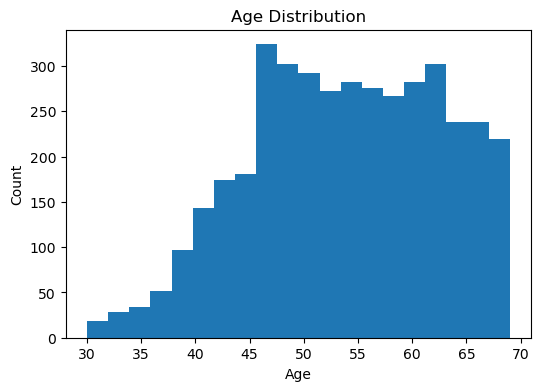

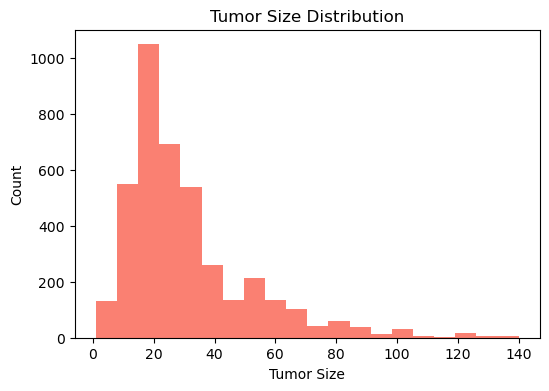

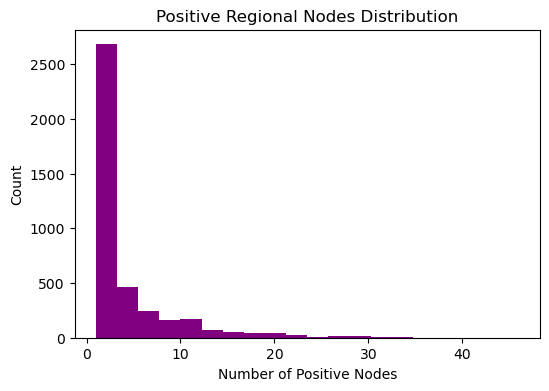

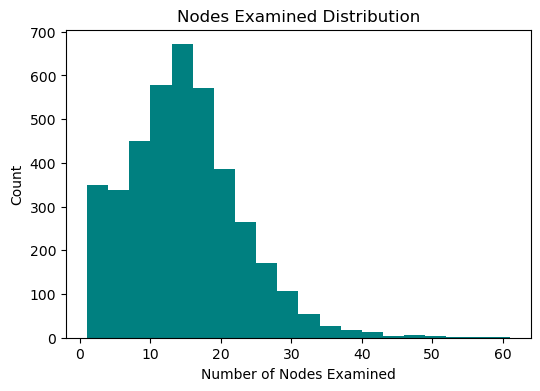

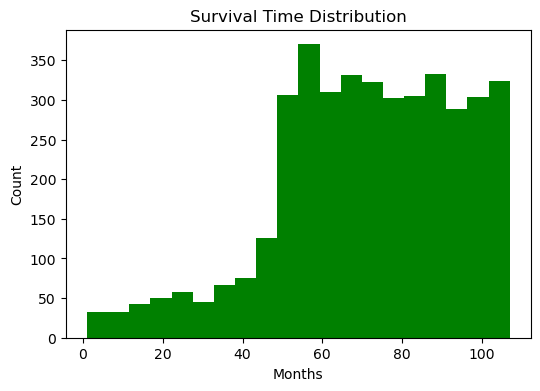

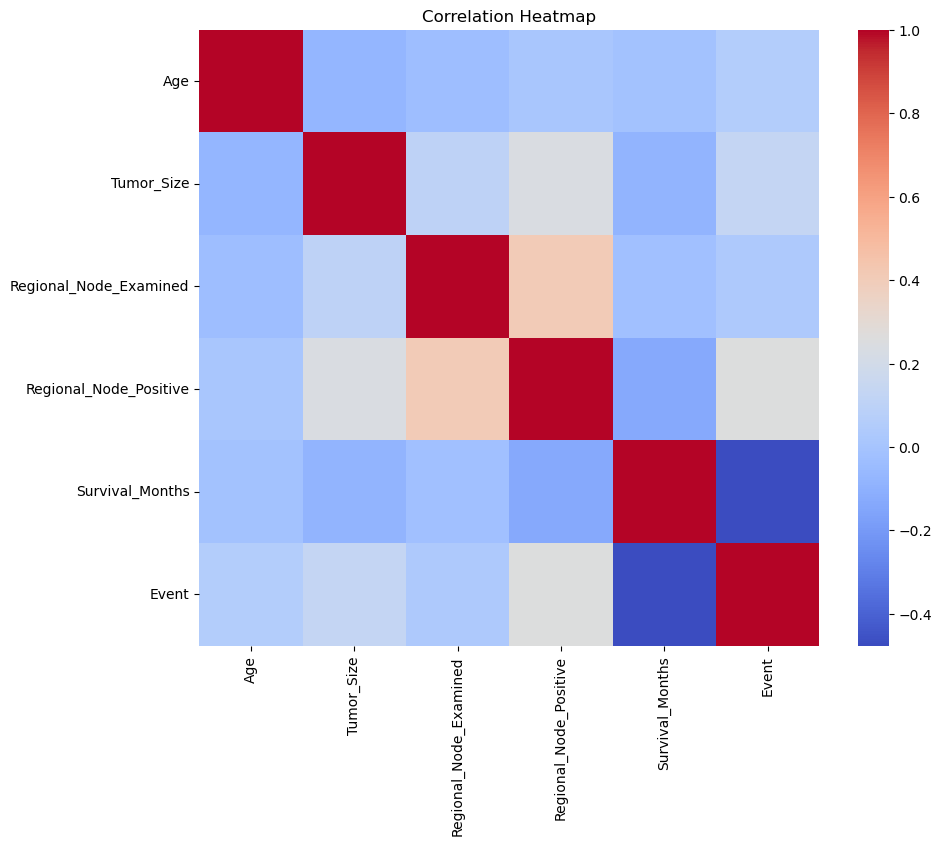

In [11]:
# ---- EDA Visualizations ----

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# 1. Age distribution
plt.figure(figsize=(6,4))
df['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(False)
plt.show()

# 2. Tumor size distribution
plt.figure(figsize=(6,4))
df['Tumor_Size'].hist(bins=20, color='salmon')
plt.title('Tumor Size Distribution')
plt.xlabel('Tumor Size')
plt.ylabel('Count')
plt.grid(False)
plt.show()

# 3. Positive nodes distribution
plt.figure(figsize=(6,4))
df['Regional_Node_Positive'].hist(bins=20, color='purple')
plt.title('Positive Regional Nodes Distribution')
plt.xlabel('Number of Positive Nodes')
plt.ylabel('Count')
plt.grid(False)
plt.show()

# 4. Nodes examined distribution
plt.figure(figsize=(6,4))
df['Regional_Node_Examined'].hist(bins=20, color='teal')
plt.title('Nodes Examined Distribution')
plt.xlabel('Number of Nodes Examined')
plt.ylabel('Count')
plt.grid(False)
plt.show()

# 5. Survival months distribution
plt.figure(figsize=(6,4))
df['Survival_Months'].hist(bins=20, color='green')
plt.title('Survival Time Distribution')
plt.xlabel('Months')
plt.ylabel('Count')
plt.grid(False)
plt.show()

# 6. Correlation heatmap for numeric features
plt.figure(figsize=(10,8))
num_cols = df.select_dtypes(include=['int64','float64']).columns
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()


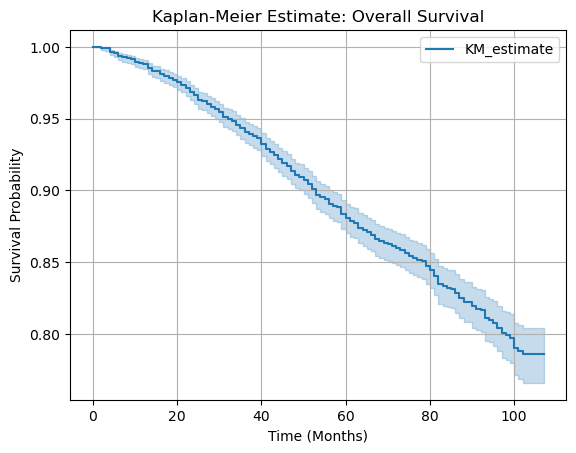

In [17]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Create a Kaplan-Meier fitter object
kmf = KaplanMeierFitter()

# Fit the model on all data
kmf.fit(durations=df['Survival_Months'], event_observed=df['Event'])

# Plot the survival curve
kmf.plot_survival_function()
plt.title('Kaplan-Meier Estimate: Overall Survival')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

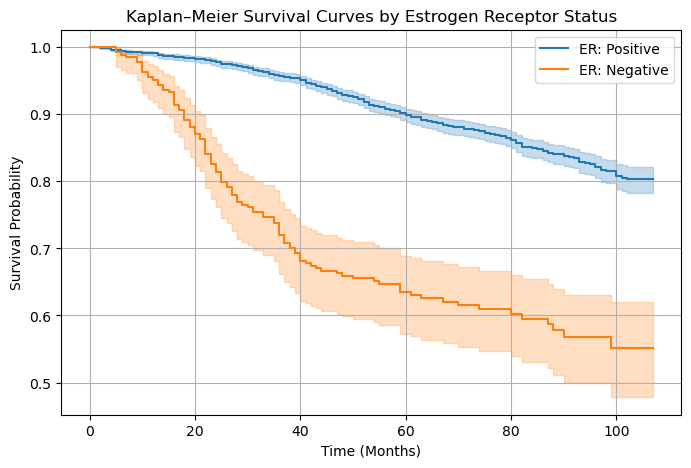

In [12]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,5))

for status in df['Estrogen_Status'].unique():
    mask = df['Estrogen_Status'] == status
    kmf.fit(
        durations=df.loc[mask, 'Survival_Months'],
        event_observed=df.loc[mask, 'Event'],
        label=f'ER: {status}'
    )
    kmf.plot_survival_function()

plt.title('Kaplan–Meier Survival Curves by Estrogen Receptor Status')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.legend()
plt.show()


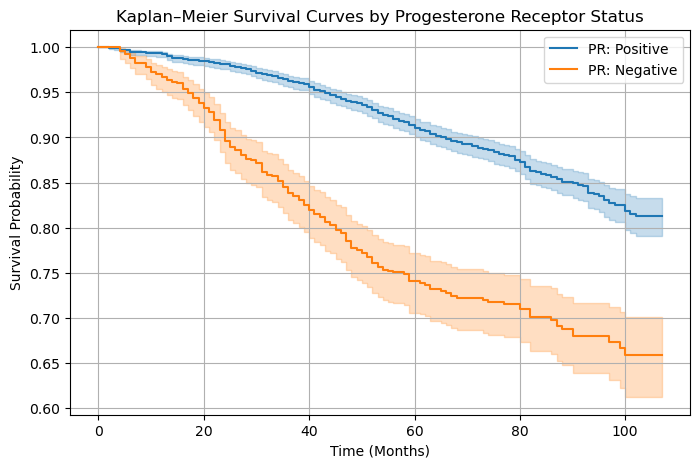

In [13]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,5))

for status in df['Progesterone_Status'].unique():
    mask = df['Progesterone_Status'] == status
    kmf.fit(
        durations=df.loc[mask, 'Survival_Months'],
        event_observed=df.loc[mask, 'Event'],
        label=f'PR: {status}'
    )
    kmf.plot_survival_function()

plt.title('Kaplan–Meier Survival Curves by Progesterone Receptor Status')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.legend()
plt.show()


In [15]:
# Create age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 50, 70, 100], labels=['<=50', '51-70', '>70'])

# Confirm distribution
print(df['Age_Group'].value_counts())

Age_Group
51-70    2526
<=50     1498
>70         0
Name: count, dtype: int64


In [16]:
from lifelines.statistics import logrank_test

# 1. Age Groups (assuming you created Age_Group earlier)
print("=== Log-rank Test: Age <=50 vs 51-70 ===")
if 'Age_Group' in df.columns:
    g1 = df[df['Age_Group'] == '<=50']
    g2 = df[df['Age_Group'] == '51-70']
    result = logrank_test(
        g1['Survival_Months'], g2['Survival_Months'],
        event_observed_A=g1['Event'], event_observed_B=g2['Event']
    )
    print(result)
else:
    print("Age_Group not found — run the age binning cell first.")

# 2. Estrogen Status
print("\n=== Log-rank Test: ER Positive vs Negative ===")
er_pos = df[df['Estrogen_Status'] == 'Positive']
er_neg = df[df['Estrogen_Status'] == 'Negative']
result_er = logrank_test(
    er_pos['Survival_Months'], er_neg['Survival_Months'],
    event_observed_A=er_pos['Event'], event_observed_B=er_neg['Event']
)
print(result_er)

# 3. Grade (Low: 1–2 vs High: 3–4)
print("\n=== Log-rank Test: Grade 1-2 vs Grade 3-4 ===")
# Convert Grade IV to 4
df['Grade'] = df['Grade'].replace({' anaplastic; Grade IV': '4'}).astype(int)

low_grade = df[df['Grade'].isin([1,2])]
high_grade = df[df['Grade'].isin([3,4])]

result_grade = logrank_test(
    low_grade['Survival_Months'], high_grade['Survival_Months'],
    event_observed_A=low_grade['Event'], event_observed_B=high_grade['Event']
)
print(result_grade)


=== Log-rank Test: Age <=50 vs 51-70 ===
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           2.93 0.09      3.52

=== Log-rank Test: ER Positive vs Negative ===
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         172.22 <0.005    128.28

=== Log-rank Test: Grade 1-2 vs Grade 3-4 ===
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          93.68 <0.005     71.19


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Loop over unique grades
for grade in df['Grade'].unique():
    kmf = KaplanMeierFitter()
    idx = df['Grade'] == grade
    kmf.fit(df.loc[idx, 'Survival_Months'], event_observed=df.loc[idx, 'Event'], label=f'Grade {grade}')
    kmf.plot_survival_function()

plt.title('Survival Curves by Tumor Grade')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.legend(title='Tumor Grade')
plt.grid(True)
plt.show()


In [ ]:
COX PH

In [19]:
# ---- CoxPH Dataset Preparation ----

from lifelines import CoxPHFitter

# Cox model needs:
# - Duration column (Survival_Months)
# - Event column (Event)
# - All other columns as features

cox_train = train_encoded.copy()
cox_test = test_encoded.copy()

print("Cox Train shape:", cox_train.shape)
print("Cox Test shape:", cox_test.shape)

print("\nColumns used in Cox model:")
print(cox_train.columns.tolist())


Cox Train shape: (2816, 30)
Cox Test shape: (1208, 30)

Columns used in Cox model:
['Age', 'Tumor_Size', 'Regional_Node_Examined', 'Regional_Node_Positive', 'Survival_Months', 'Event', 'Race_Other', 'Race_White', 'Marital_Status_Married', 'Marital_Status_Separated', 'Marital_Status_Single ', 'Marital_Status_Widowed', 'T Stage _T2', 'T Stage _T3', 'T Stage _T4', 'N Stage_N2', 'N Stage_N3', '6th Stage_IIB', '6th Stage_IIIA', '6th Stage_IIIB', '6th Stage_IIIC', 'differentiate_Poorly differentiated', 'differentiate_Undifferentiated', 'differentiate_Well differentiated', 'Grade_1', 'Grade_2', 'Grade_3', 'A Stage_Regional', 'Estrogen_Status_Positive', 'Progesterone_Status_Positive']


In [21]:
# ---- Remove collinear staging features before fitting Cox ----

cox_train_reduced = cox_train.drop(columns=[
    '6th Stage_IIB', '6th Stage_IIIA', '6th Stage_IIIB', '6th Stage_IIIC',
    'A Stage_Regional'
], errors='ignore')

cox_test_reduced = cox_test.drop(columns=[
    '6th Stage_IIB', '6th Stage_IIIA', '6th Stage_IIIB', '6th Stage_IIIC',
    'A Stage_Regional'
], errors='ignore')

print("Reduced Cox Train shape:", cox_train_reduced.shape)
print("Reduced Cox Test shape:", cox_test_reduced.shape)
print("Remaining columns:", cox_train_reduced.columns.tolist())


Reduced Cox Train shape: (2816, 25)
Reduced Cox Test shape: (1208, 25)
Remaining columns: ['Age', 'Tumor_Size', 'Regional_Node_Examined', 'Regional_Node_Positive', 'Survival_Months', 'Event', 'Race_Other', 'Race_White', 'Marital_Status_Married', 'Marital_Status_Separated', 'Marital_Status_Single ', 'Marital_Status_Widowed', 'T Stage _T2', 'T Stage _T3', 'T Stage _T4', 'N Stage_N2', 'N Stage_N3', 'differentiate_Poorly differentiated', 'differentiate_Undifferentiated', 'differentiate_Well differentiated', 'Grade_1', 'Grade_2', 'Grade_3', 'Estrogen_Status_Positive', 'Progesterone_Status_Positive']


In [22]:
# ---- Fit Cox Model with Penalizer ----

cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    cox_train_reduced,
    duration_col='Survival_Months',
    event_col='Event'
)

print("Cox model fitted successfully with penalizer.")
cph.print_summary()


Cox model fitted successfully with penalizer.


<lifelines.CoxPHFitter: fitted with 2816 total observations, 2385 right-censored observations>
             duration col = 'Survival_Months'
                event col = 'Event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 2816
number of events observed = 431
   partial log-likelihood = -3142.93
         time fit was run = 2025-11-29 00:31:31 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
Age                                  0.01      1.01      0.00            0.00            0.02                1.00                1.02
Tumor_Size                           0.00      1.00      0.00            0.00            0.01                1.00                1.01
Regional_Node_Examined              -0.01      0.99      0.01           -0.02           -0.01                0.98                0.99
Regional_Node_Positive               0.04      1.04      0.01            0.02            0.05                1.02                1.05
Race_Other                          -0.28      0.76      0.16           -0.58            0.02                0.56                1.02
Race_White                          -0.17      0.84      0.11           -0.39            0.05                0.68                1.05
Marital_Status_Married              -0.16      0.85      0.09           -0.33            0.01                0.72                1.01
Marital_Status_Separated             0.41      1.51      0.30           -0.18            1.01                0.84                2.74
Marital_Status_Single                0.05      1.06      0.11           -0.16            0.27                0.85                1.31
Marital_Status_Widowed               0.14      1.15      0.16           -0.17            0.45                0.85                1.56
T Stage _T2                          0.19      1.21      0.08            0.03            0.35                1.03                1.42
T Stage _T3                          0.11      1.11      0.13           -0.14            0.35                0.87                1.42
T Stage _T4                          0.51      1.66      0.20            0.13            0.89                1.13                2.44
N Stage_N2                           0.25      1.28      0.09            0.06            0.43                1.06                1.53
N Stage_N3                           0.53      1.70      0.12            0.29            0.77                1.33                2.17
differentiate_Poorly differentiated  0.14      1.15      0.11           -0.08            0.36                0.92                1.43
differentiate_Undifferentiated       0.75      2.12      0.41           -0.06            1.56                0.95                4.77
differentiate_Well differentiated   -0.16      0.85      0.15           -0.46            0.13                0.63                1.14
Grade_1                             -0.16      0.85      0.15           -0.46            0.13                0.63                1.14
Grade_2                             -0.05      0.95      0.10           -0.25            0.14                0.78                1.16
Grade_3                              0.14      1.15      0.11           -0.08            0.36                0.92                1.43
Estrogen_Status_Positive            -0.67      0.51      0.13           -0.92           -0.41                0.40                0.66
Progesterone_Status_Positive        -0.41      0.66      0.10           -0.61           -0.22                0.55                0.80

                                     cmp to     z      p  -log2(p)
covariate                                                         
Age                                    0.00  2.24   0.03      5.31
Tumor_Size  

In [23]:
from lifelines.utils import concordance_index

test_risk_scores = cph.predict_partial_hazard(cox_test_reduced)

c_index_test = concordance_index(
    cox_test_reduced['Survival_Months'],
    -test_risk_scores,
    cox_test_reduced['Event']
)

print("Test C-index (CoxPH):", c_index_test)


Test C-index (CoxPH): 0.7142824675140199


In [25]:
# ---- Fit Cox PH Model with Stratification for ER and PR ----

cph_strat = CoxPHFitter(penalizer=0.1)

cph_strat.fit(
    cox_train_reduced,
    duration_col='Survival_Months',
    event_col='Event',
    strata=['Estrogen_Status_Positive', 'Progesterone_Status_Positive']
)

print("Stratified Cox model fitted successfully.")
cph_strat.print_summary()


Stratified Cox model fitted successfully.


model,lifelines.CoxPHFitter
duration col,'Survival_Months'
event col,'Event'
penalizer,0.1
l1 ratio,0.0
strata,"[Estrogen_Status_Positive, Progesterone_Status..."
baseline estimation,breslow
number of observations,2816
number of events observed,431
partial log-likelihood,-2739.72
time fit was run,2025-11-29 00:36:05 UTC


In [26]:
from lifelines.utils import concordance_index

test_risk_scores_strat = cph_strat.predict_partial_hazard(cox_test_reduced)

c_index_test_strat = concordance_index(
    cox_test_reduced['Survival_Months'],
    -test_risk_scores_strat,
    cox_test_reduced['Event']
)

print("Stratified CoxPH Test C-index:", c_index_test_strat)


Stratified CoxPH Test C-index: 0.7062312854050307


In [27]:
# ---- Proportional Hazards Assumption Test ----

ph_test = cph.check_assumptions(cox_train_reduced, p_value_threshold=0.05)


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 2816 total observations, 2385 right-censored observations>
         test_name = proportional_hazard_test

---
                                          test_statistic      p  -log2(p)
Age                                 km              0.01   0.92      0.12
                                    rank            0.00   0.98      0.03
Estrogen_Status_Positive            km             11.70 <0.005     10.65
                                    rank           14.50 <0.005     12.80
Grade_1                             km              0.00   0.97      0.04
                                    rank            0.00   0.98      0.04
Grade_2                             km              0.05   0.83      0.27
                                    rank            0.04   0.83      0.26
Grade_3                             km              0.03   0.85      0.23
                                    rank            0.03   0.86      0.22
Marital_Status_Married              km              0.65   0.42      1.25
                                    rank            0.71   0.40      1.32
Marital_Status_Separated            km              0.06   0.80      0.31
                                    rank            0.09   0.76      0.39
Marital_Status_Single               km              0.37   0.54      0.88
                                    rank            0.45   0.50      0.99
Marital_Status_Widowed              km              0.09   0.76      0.39
                                    rank            0.04   0.85      0.24
N Stage_N2                          km              1.41   0.23      2.09
                                    rank            1.58   0.21      2.26
N Stage_N3                          km              1.72   0.19      2.40
                                    rank            1.58   0.21      2.26
Progesterone_Status_Positive        km              8.00 <0.005      7.74
                                    rank            7.44   0.01      7.29
Race_Other                          km              0.16   0.69      0.53
                                    rank            0.05   0.83      0.27
Race_White                          km              0.00   0.96      0.06
                                    rank            0.01   0.93      0.11
Regional_Node_Examined              km              0.02   0.90      0.16
                                    rank            0.00   0.97      0.05
Regional_Node_Positive              km              0.25   0.62      0.70
                                    rank            0.24   0.63      0.68
T Stage _T2                         km              0.65   0.42      1.25
                                    rank            0.68   0.41      1.28
T Stage _T3                         km              0.20   0.66      0.61
                                    rank            0.09   0.76      0.39
T Stage _T4                         km              0.00   0.94      0.08
                                    rank            0.00   0.98      0.03
Tumor_Size                          km              0.94   0.33      1.59
                                    rank            1.01   0.31      1.67
differentiate_Poorly differentiated km              0.03   0.85      0.23
                                    rank            0.03   0.86      0.22
differentiate_Undifferentiated      km              0.14   0.71      0.50
                                    rank            0.16   0.69      0.54
differentiate_Well differentiated   km              0.00   0.97      0.04
                                    rank            0.00   0.98      0.04



1. Variable 'Estrogen_Status_Positive' failed the non-proportional test: p-value is 0.0001.

   Advice: with so few unique values (only 2), you can include `strata=['Estrogen_Status_Positive',
...]` in the call in `.fit`. See documentation in link [E] below.

2. Variable 'Progesterone_Status_Positive' failed the non-proportional test: p-value is 0.0047.

   Advice: with so few unique values (only 2), you can include
`strata=['Progesterone_Status_Positive', ...]` in the call in `.fit`. See documentation in link [E]
below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20h


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin

C:\Anaconda\Lib\site-packages\lifelines\fitters\mixins.py:123: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.2207)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9108)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1749)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3722)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7500)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8638)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4212)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5519)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6819)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6802)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1927)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9063)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7519)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4124)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6489)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7898)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2875)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5114)'>],
 [<Axes: xlabel='rank-transformed tim

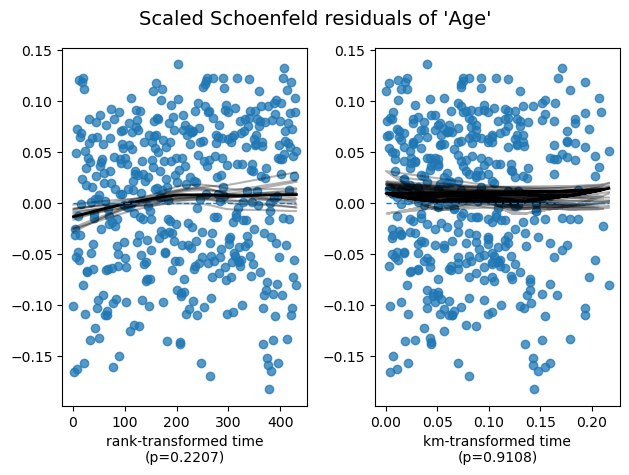

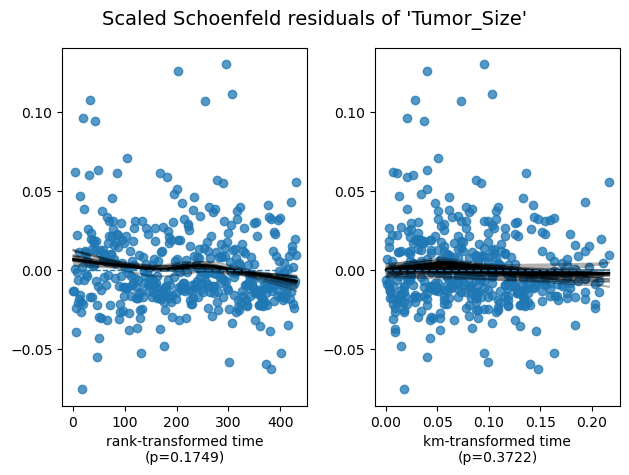

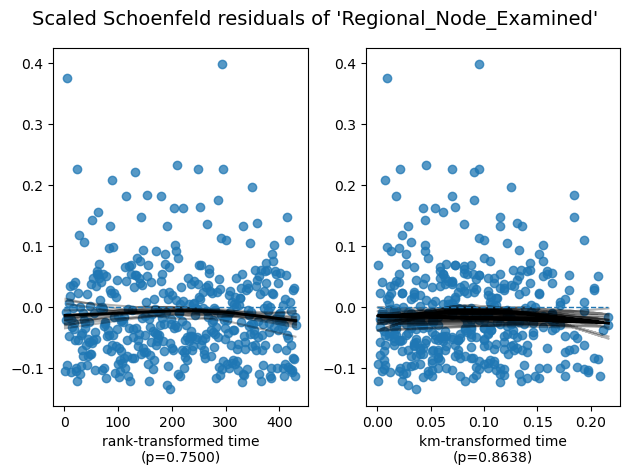

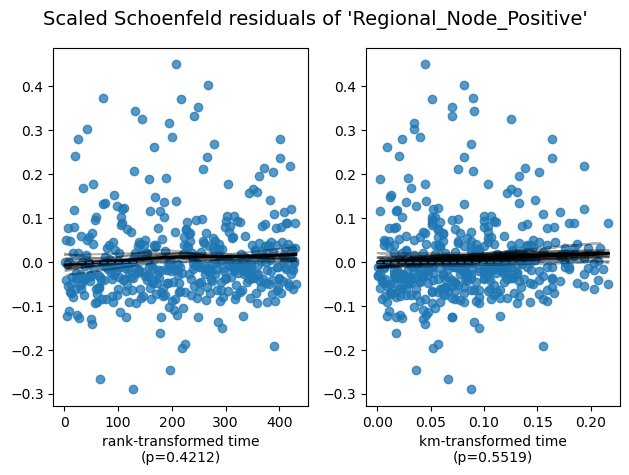

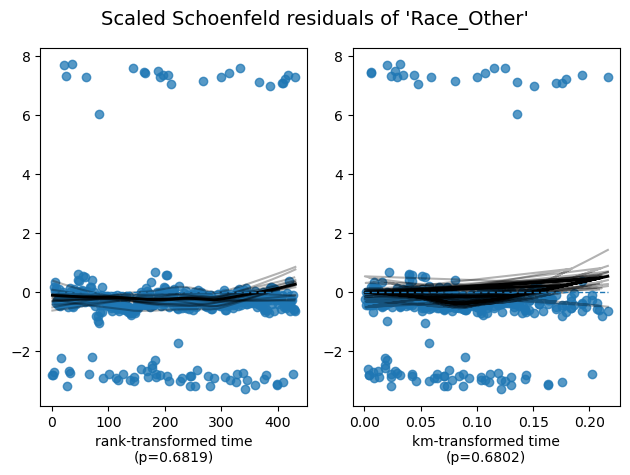

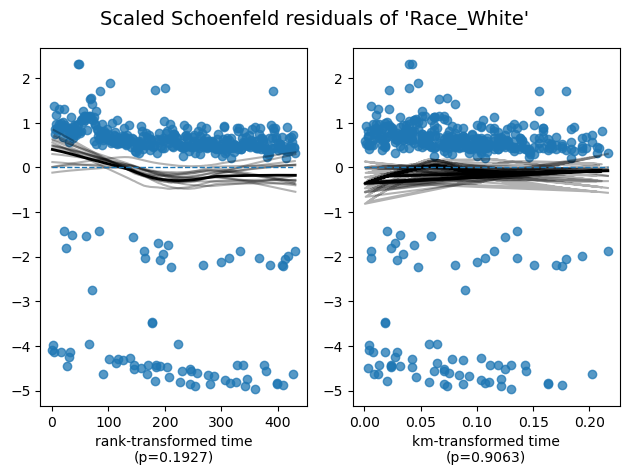

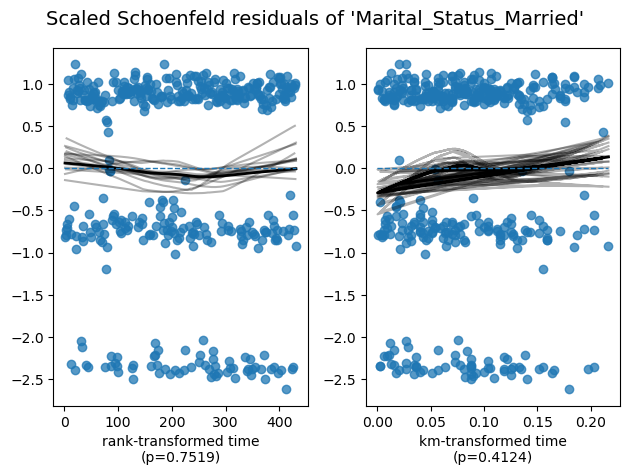

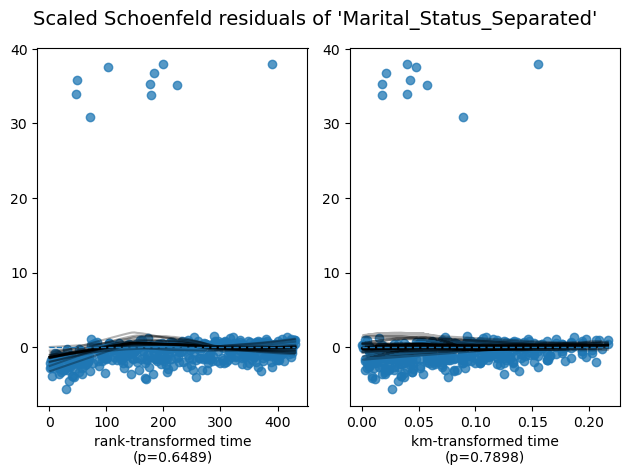

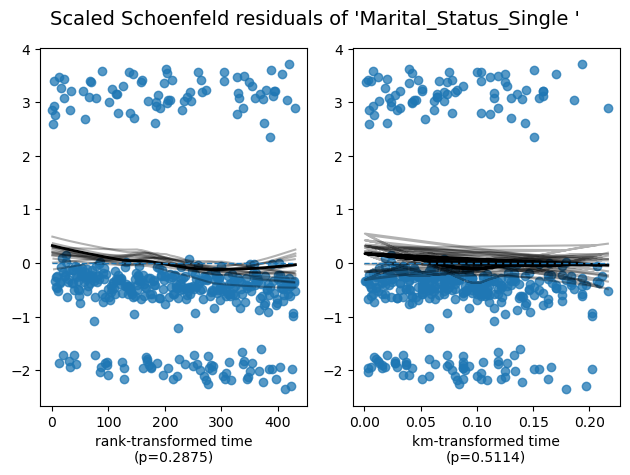

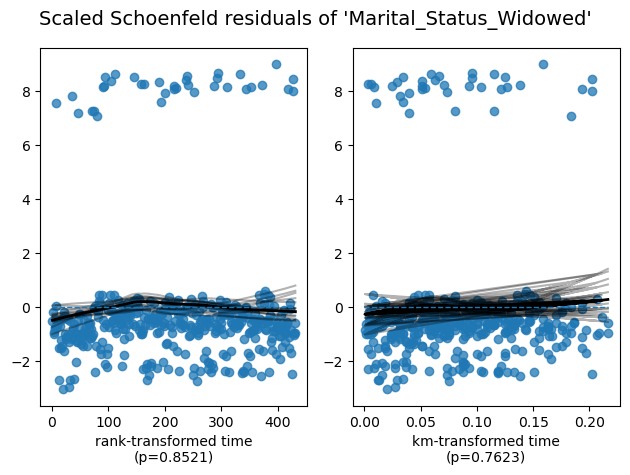

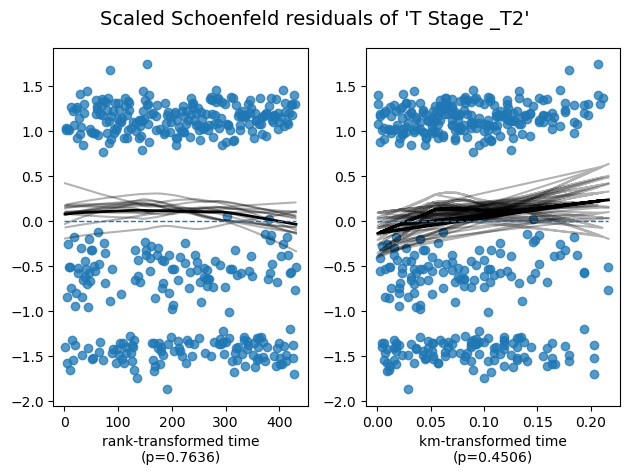

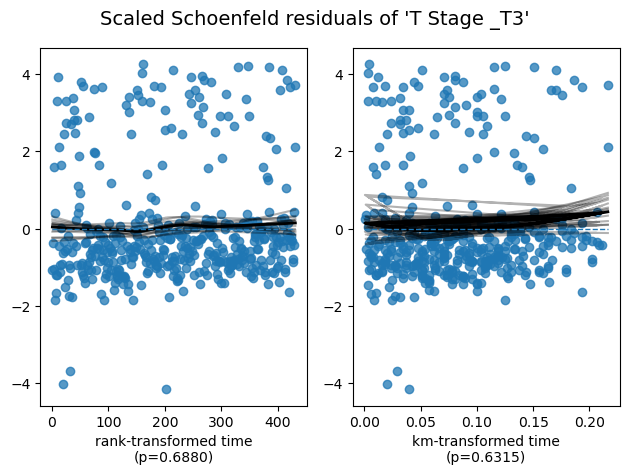

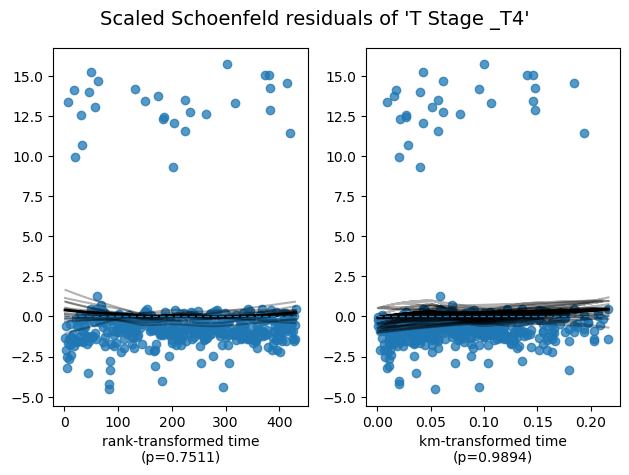

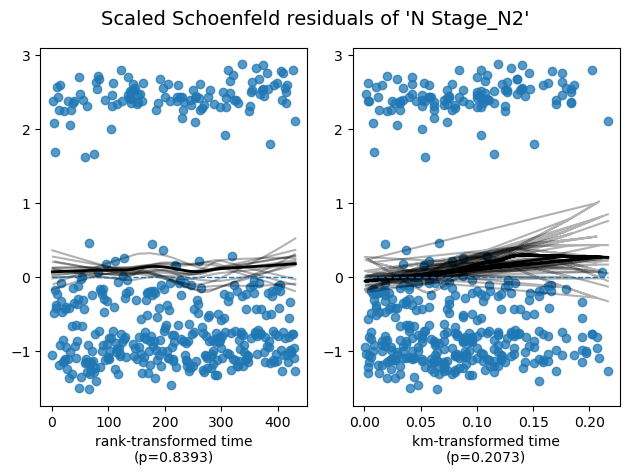

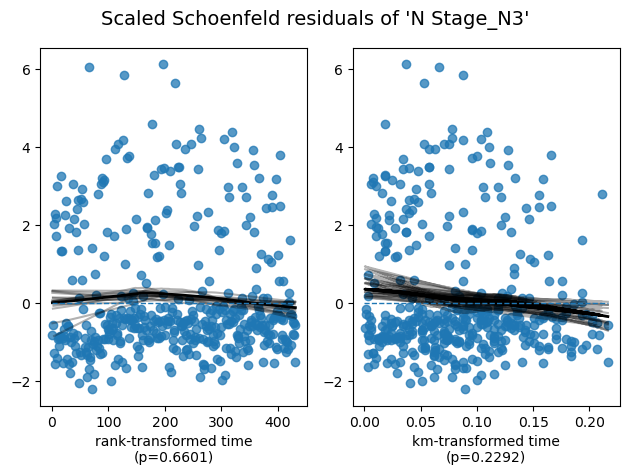

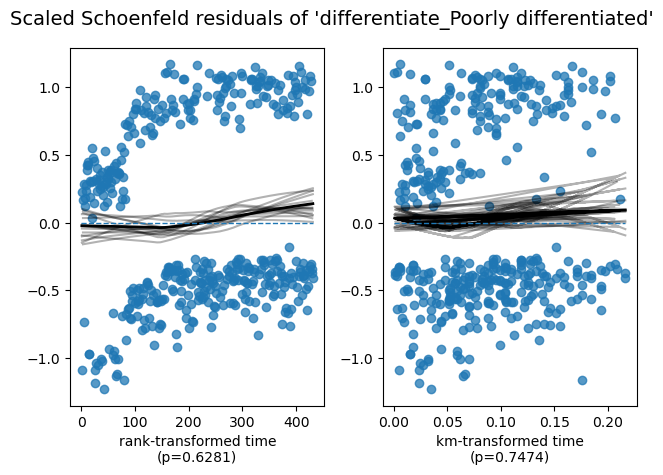

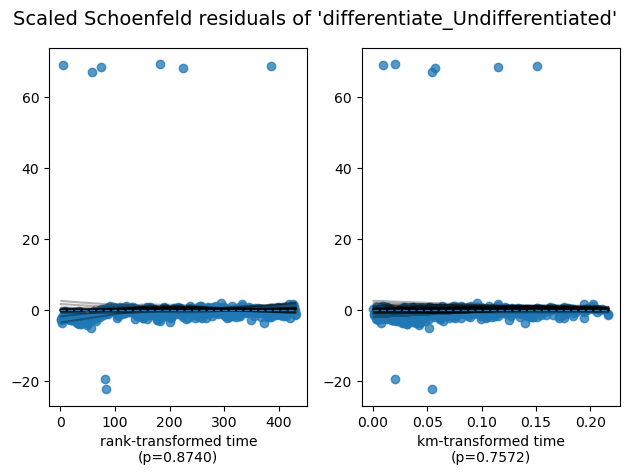

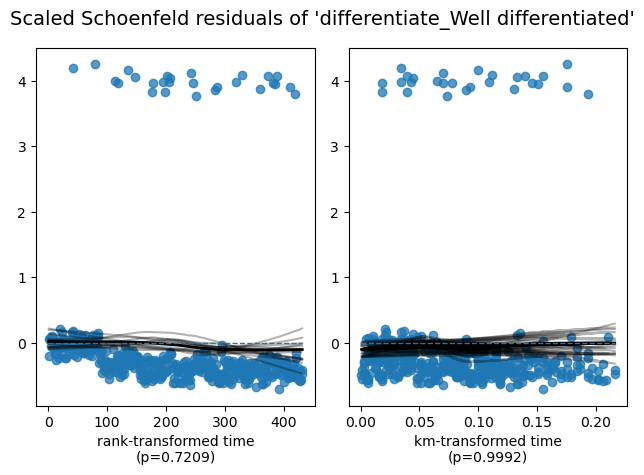

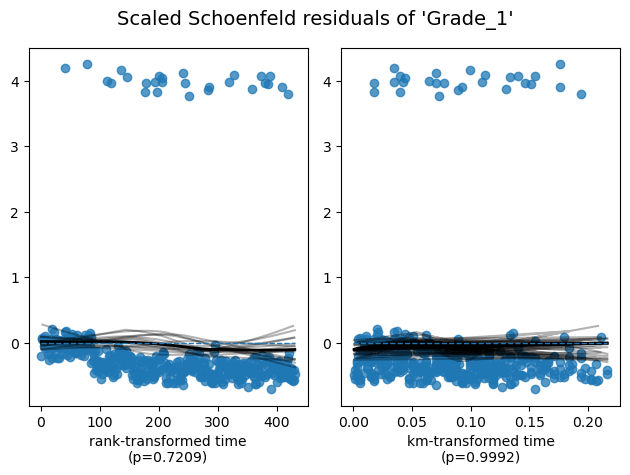

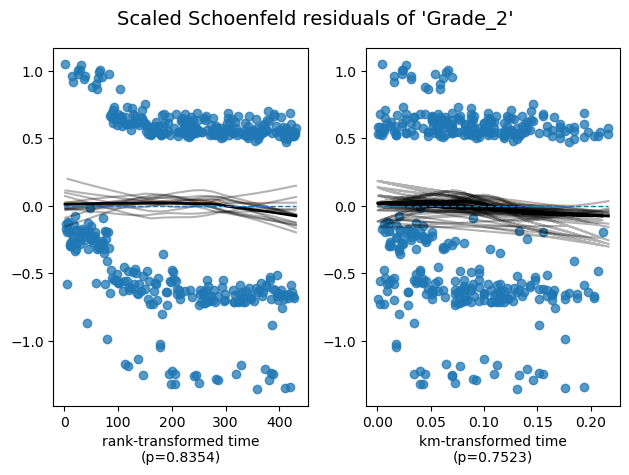

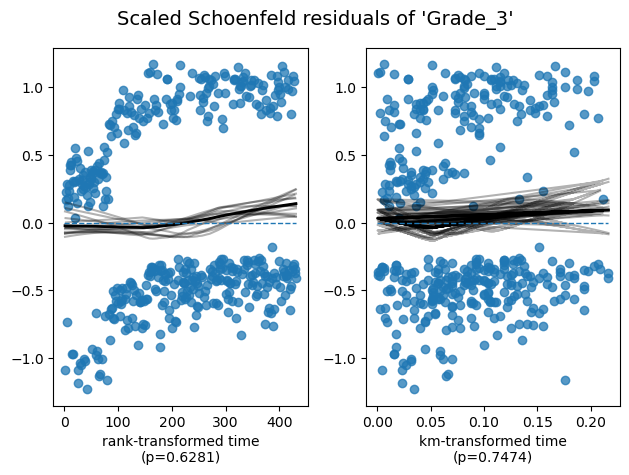

In [28]:
# ---- Schoenfeld Residual Diagnostic Plots for Stratified Cox Model ----

cph_strat.check_assumptions(
    cox_train_reduced,
    p_value_threshold=0.05,
    show_plots=True
)


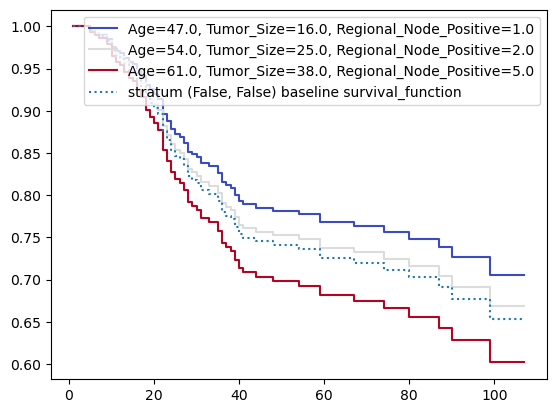

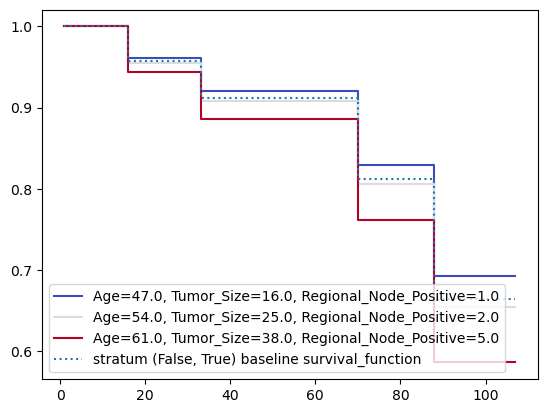

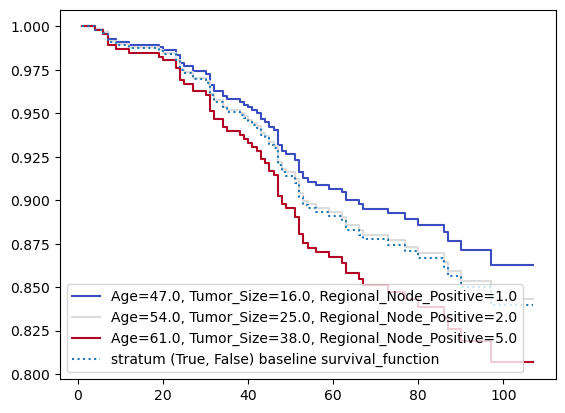

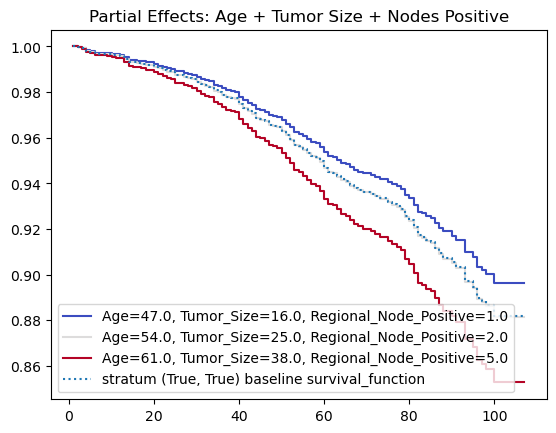

In [30]:
import numpy as np

values = np.array([
    [df['Age'].quantile(0.25), df['Tumor_Size'].quantile(0.25), df['Regional_Node_Positive'].quantile(0.25)],
    [df['Age'].quantile(0.50), df['Tumor_Size'].quantile(0.50), df['Regional_Node_Positive'].quantile(0.50)],
    [df['Age'].quantile(0.75), df['Tumor_Size'].quantile(0.75), df['Regional_Node_Positive'].quantile(0.75)],
])

cph_strat.plot_partial_effects_on_outcome(
    covariates=['Age', 'Tumor_Size', 'Regional_Node_Positive'],
    values=values,
    cmap="coolwarm"
)
plt.title("Partial Effects: Age + Tumor Size + Nodes Positive")
plt.show()


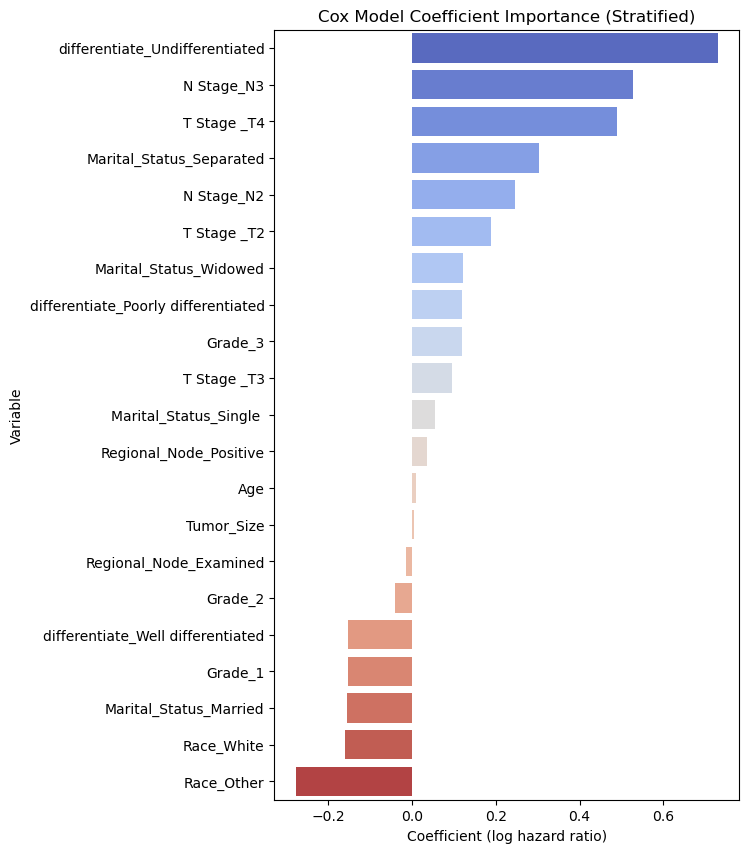

In [31]:
# ---- Coefficient Importance Visualization ----

import seaborn as sns
import matplotlib.pyplot as plt

coef_df = cph_strat.summary[['coef']].sort_values(by='coef', ascending=False)

plt.figure(figsize=(6,10))
sns.barplot(x='coef', y=coef_df.index, data=coef_df, palette='coolwarm')
plt.title("Cox Model Coefficient Importance (Stratified)")
plt.xlabel("Coefficient (log hazard ratio)")
plt.ylabel("Variable")
plt.show()


In [ ]:
RSF

In [32]:
# ---- RSF DATA PREPARATION ----

from sksurv.util import Surv
import numpy as np

# Remove survival columns from features
X_train_rsf = cox_train_reduced.drop(columns=['Survival_Months', 'Event'])
X_test_rsf  = cox_test_reduced.drop(columns=['Survival_Months', 'Event'])

# Create structured survival arrays
y_train_rsf = Surv.from_arrays(
    event=cox_train_reduced['Event'].astype(bool),
    time=cox_train_reduced['Survival_Months']
)

y_test_rsf = Surv.from_arrays(
    event=cox_test_reduced['Event'].astype(bool),
    time=cox_test_reduced['Survival_Months']
)

print("X_train_rsf shape:", X_train_rsf.shape)
print("X_test_rsf shape:", X_test_rsf.shape)
print("\nSample of y_train_rsf:")
print(y_train_rsf[:5])


X_train_rsf shape: (2816, 23)
X_test_rsf shape: (1208, 23)

Sample of y_train_rsf:
[(False, 65.) (False, 83.) ( True, 43.) ( True, 10.) (False, 99.)]


In [33]:
# ---- BASE RANDOM SURVIVAL FOREST MODEL ----

from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=300,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train_rsf, y_train_rsf)

print("RSF model trained successfully!")
print("Number of trees:", len(rsf.estimators_))


RSF model trained successfully!
Number of trees: 300


In [36]:
from sksurv.metrics import concordance_index_censored
import numpy as np

# RSF survival functions
rsf_surv_funcs = rsf.predict_survival_function(X_test_rsf)

# Compute mean survival time
rsf_mean_survival = np.array([
    np.trapz(fn.y, fn.x) for fn in rsf_surv_funcs
])

# NEGATE the survival time => higher risk → lower score
rsf_risk_score = -rsf_mean_survival

c_index_rsf = concordance_index_censored(
    event_indicator=cox_test_reduced['Event'].astype(bool),
    event_time=cox_test_reduced['Survival_Months'],
    estimate=rsf_risk_score
)[0]

print("Corrected RSF C-index:", c_index_rsf)


Corrected RSF C-index: 0.7007937545099688


In [37]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
import numpy as np

results = []

n_estimators_list = [200, 400, 600]
max_features_list = ["sqrt", "log2", 0.5]
min_samples_split_list = [5, 10, 20]
min_samples_leaf_list = [2, 5, 10]

for n in n_estimators_list:
    for mf in max_features_list:
        for mss in min_samples_split_list:
            for msl in min_samples_leaf_list:

                rsf_tmp = RandomSurvivalForest(
                    n_estimators=n,
                    max_features=mf,
                    min_samples_split=mss,
                    min_samples_leaf=msl,
                    n_jobs=-1,
                    random_state=42
                )

                rsf_tmp.fit(X_train_rsf, y_train_rsf)

                # Predict survival functions
                surv_tmp = rsf_tmp.predict_survival_function(X_test_rsf)

                # Compute mean survival time
                mean_surv_tmp = np.array([
                    np.trapz(fn.y, fn.x) for fn in surv_tmp
                ])

                # Convert to risk direction (higher risk = higher score)
                risk_tmp = -mean_surv_tmp

                c_index_tmp = concordance_index_censored(
                    event_indicator=cox_test_reduced['Event'].astype(bool),
                    event_time=cox_test_reduced['Survival_Months'],
                    estimate=risk_tmp
                )[0]

                results.append((n, mf, mss, msl, c_index_tmp))
                print(f"n={n}, max_features={mf}, split={mss}, leaf={msl} -> C-index={c_index_tmp:.4f}")


n=200, max_features=sqrt, split=5, leaf=2 -> C-index=0.6943
n=200, max_features=sqrt, split=5, leaf=5 -> C-index=0.7008
n=200, max_features=sqrt, split=5, leaf=10 -> C-index=0.7011
n=200, max_features=sqrt, split=10, leaf=2 -> C-index=0.6959
n=200, max_features=sqrt, split=10, leaf=5 -> C-index=0.7008
n=200, max_features=sqrt, split=10, leaf=10 -> C-index=0.7011
n=200, max_features=sqrt, split=20, leaf=2 -> C-index=0.6989
n=200, max_features=sqrt, split=20, leaf=5 -> C-index=0.7035
n=200, max_features=sqrt, split=20, leaf=10 -> C-index=0.7011
n=200, max_features=log2, split=5, leaf=2 -> C-index=0.6943
n=200, max_features=log2, split=5, leaf=5 -> C-index=0.7008
n=200, max_features=log2, split=5, leaf=10 -> C-index=0.7011
n=200, max_features=log2, split=10, leaf=2 -> C-index=0.6959
n=200, max_features=log2, split=10, leaf=5 -> C-index=0.7008
n=200, max_features=log2, split=10, leaf=10 -> C-index=0.7011
n=200, max_features=log2, split=20, leaf=2 -> C-index=0.6989
n=200, max_features=log2,

In [38]:
best = max(results, key=lambda x: x[4])
print("\nBest Hyperparameters:")
print("n_estimators:", best[0])
print("max_features:", best[1])
print("min_samples_split:", best[2])
print("min_samples_leaf:", best[3])
print("Best C-index:", best[4])



Best Hyperparameters:
n_estimators: 200
max_features: sqrt
min_samples_split: 20
min_samples_leaf: 5
Best C-index: 0.7035494519855227


In [39]:
results2 = []

n_estimators_list = [400, 600, 800]
max_depth_list = [None, 10, 20]
max_features_list = ["sqrt", "log2"]
min_samples_split_list = [5, 10, 20, 40]
min_samples_leaf_list = [2, 5, 10]

for n in n_estimators_list:
    for md in max_depth_list:
        for mf in max_features_list:
            for mss in min_samples_split_list:
                for msl in min_samples_leaf_list:

                    rsf_tmp = RandomSurvivalForest(
                        n_estimators=n,
                        max_depth=md,
                        max_features=mf,
                        min_samples_split=mss,
                        min_samples_leaf=msl,
                        n_jobs=-1,
                        random_state=42
                    )

                    rsf_tmp.fit(X_train_rsf, y_train_rsf)

                    surv_tmp = rsf_tmp.predict_survival_function(X_test_rsf)

                    mean_surv_tmp = np.array([
                        np.trapz(fn.y, fn.x) for fn in surv_tmp
                    ])

                    risk_tmp = -mean_surv_tmp

                    c_index_tmp = concordance_index_censored(
                        event_indicator=cox_test_reduced['Event'].astype(bool),
                        event_time=cox_test_reduced['Survival_Months'],
                        estimate=risk_tmp
                    )[0]

                    results2.append((n, md, mf, mss, msl, c_index_tmp))
                    print(f"n={n}, depth={md}, maxf={mf}, split={mss}, leaf={msl} -> C={c_index_tmp:.4f}")


n=400, depth=None, maxf=sqrt, split=5, leaf=2 -> C=0.6940
n=400, depth=None, maxf=sqrt, split=5, leaf=5 -> C=0.7010
n=400, depth=None, maxf=sqrt, split=5, leaf=10 -> C=0.7028
n=400, depth=None, maxf=sqrt, split=10, leaf=2 -> C=0.6962
n=400, depth=None, maxf=sqrt, split=10, leaf=5 -> C=0.7010
n=400, depth=None, maxf=sqrt, split=10, leaf=10 -> C=0.7028
n=400, depth=None, maxf=sqrt, split=20, leaf=2 -> C=0.6982
n=400, depth=None, maxf=sqrt, split=20, leaf=5 -> C=0.7033
n=400, depth=None, maxf=sqrt, split=20, leaf=10 -> C=0.7028
n=400, depth=None, maxf=sqrt, split=40, leaf=2 -> C=0.7024
n=400, depth=None, maxf=sqrt, split=40, leaf=5 -> C=0.7061
n=400, depth=None, maxf=sqrt, split=40, leaf=10 -> C=0.7049
n=400, depth=None, maxf=log2, split=5, leaf=2 -> C=0.6940
n=400, depth=None, maxf=log2, split=5, leaf=5 -> C=0.7010
n=400, depth=None, maxf=log2, split=5, leaf=10 -> C=0.7028
n=400, depth=None, maxf=log2, split=10, leaf=2 -> C=0.6962
n=400, depth=None, maxf=log2, split=10, leaf=5 -> C=0.701

n=600, depth=20, maxf=log2, split=40, leaf=5 -> C=0.7061
n=600, depth=20, maxf=log2, split=40, leaf=10 -> C=0.7063
n=800, depth=None, maxf=sqrt, split=5, leaf=2 -> C=0.6936
n=800, depth=None, maxf=sqrt, split=5, leaf=5 -> C=0.7016
n=800, depth=None, maxf=sqrt, split=5, leaf=10 -> C=0.7032
n=800, depth=None, maxf=sqrt, split=10, leaf=2 -> C=0.6965
n=800, depth=None, maxf=sqrt, split=10, leaf=5 -> C=0.7016
n=800, depth=None, maxf=sqrt, split=10, leaf=10 -> C=0.7032
n=800, depth=None, maxf=sqrt, split=20, leaf=2 -> C=0.6983
n=800, depth=None, maxf=sqrt, split=20, leaf=5 -> C=0.7022
n=800, depth=None, maxf=sqrt, split=20, leaf=10 -> C=0.7032
n=800, depth=None, maxf=sqrt, split=40, leaf=2 -> C=0.7038
n=800, depth=None, maxf=sqrt, split=40, leaf=5 -> C=0.7054
n=800, depth=None, maxf=sqrt, split=40, leaf=10 -> C=0.7056
n=800, depth=None, maxf=log2, split=5, leaf=2 -> C=0.6936
n=800, depth=None, maxf=log2, split=5, leaf=5 -> C=0.7016
n=800, depth=None, maxf=log2, split=5, leaf=10 -> C=0.7032
n

In [40]:
best2 = max(results2, key=lambda x: x[5])
print("\nBEST ADVANCED RSF HYPERPARAMETERS:")
print("n_estimators:", best2[0])
print("max_depth:", best2[1])
print("max_features:", best2[2])
print("min_samples_split:", best2[3])
print("min_samples_leaf:", best2[4])
print("BEST C-index:", best2[5])



BEST ADVANCED RSF HYPERPARAMETERS:
n_estimators: 600
max_depth: None
max_features: sqrt
min_samples_split: 40
min_samples_leaf: 10
BEST C-index: 0.7062994676106115


Testing importance for feature: Age
Testing importance for feature: Tumor_Size
Testing importance for feature: Regional_Node_Examined
Testing importance for feature: Regional_Node_Positive
Testing importance for feature: Race_Other
Testing importance for feature: Race_White
Testing importance for feature: Marital_Status_Married
Testing importance for feature: Marital_Status_Separated
Testing importance for feature: Marital_Status_Single 
Testing importance for feature: Marital_Status_Widowed
Testing importance for feature: T Stage _T2
Testing importance for feature: T Stage _T3
Testing importance for feature: T Stage _T4
Testing importance for feature: N Stage_N2
Testing importance for feature: N Stage_N3
Testing importance for feature: differentiate_Poorly differentiated
Testing importance for feature: differentiate_Undifferentiated
Testing importance for feature: differentiate_Well differentiated
Testing importance for feature: Grade_1
Testing importance for feature: Grade_2
Testing 

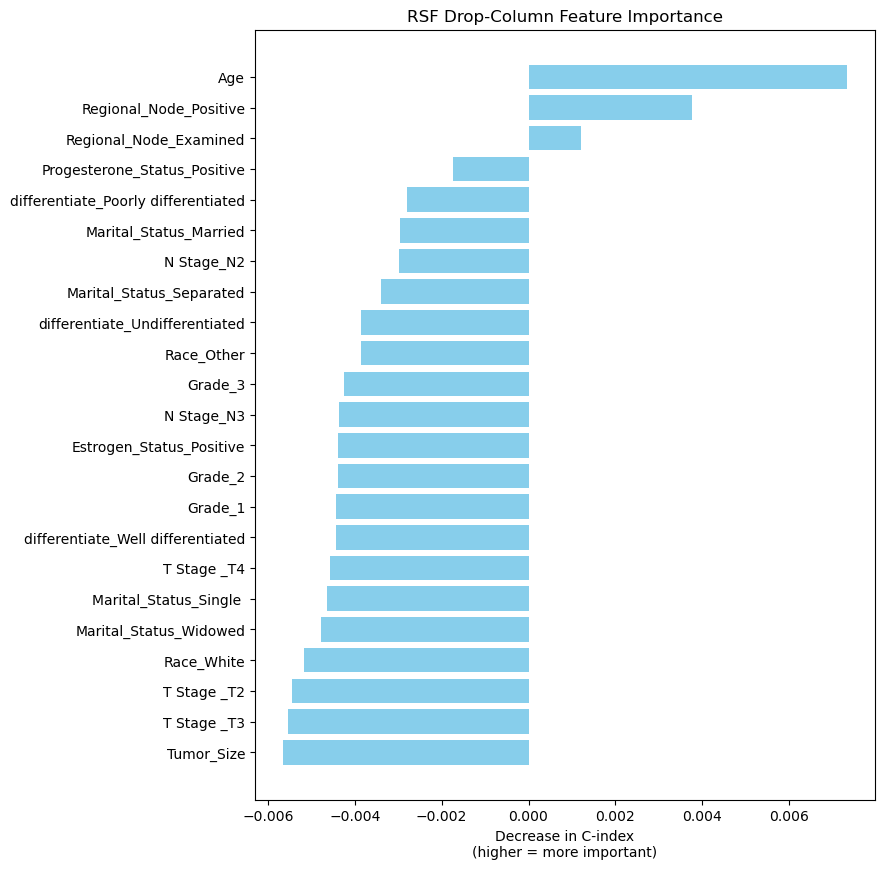

In [44]:
# ---- Drop-Column Feature Importance for RSF ----

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
import numpy as np

def compute_cindex(model, X, y):
    surv_funcs = model.predict_survival_function(X)
    mean_surv = np.array([np.trapz(fn.y, fn.x) for fn in surv_funcs])
    risk = -mean_surv
    return concordance_index_censored(y['event'], y['time'], risk)[0]

# Prepare full y_test_struct
y_test_struct = np.zeros(len(y_test_rsf), dtype=[('event', bool), ('time', float)])
y_test_struct['event'] = y_test_rsf['event']
y_test_struct['time'] = y_test_rsf['time']

# BASELINE performance
baseline_cindex = compute_cindex(rsf, X_test_rsf, y_test_struct)

importances = []
feature_names = X_train_rsf.columns

for col in feature_names:
    print(f"Testing importance for feature: {col}")

    X_train_drop = X_train_rsf.drop(columns=[col])
    X_test_drop = X_test_rsf.drop(columns=[col])

    rsf_tmp = RandomSurvivalForest(
        n_estimators=600,
        max_depth=None,
        max_features="sqrt",
        min_samples_split=40,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    )

    rsf_tmp.fit(X_train_drop, y_train_rsf)

    cindex_drop = compute_cindex(rsf_tmp, X_test_drop, y_test_struct)

    importance_value = baseline_cindex - cindex_drop
    importances.append(importance_value)

# Convert to array and sort
importances = np.array(importances)
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(8, 10))
plt.barh(feature_names[indices], importances[indices], color='skyblue')
plt.title("RSF Drop-Column Feature Importance")
plt.xlabel("Decrease in C-index\n(higher = more important)")
plt.gca().invert_yaxis()
plt.show()


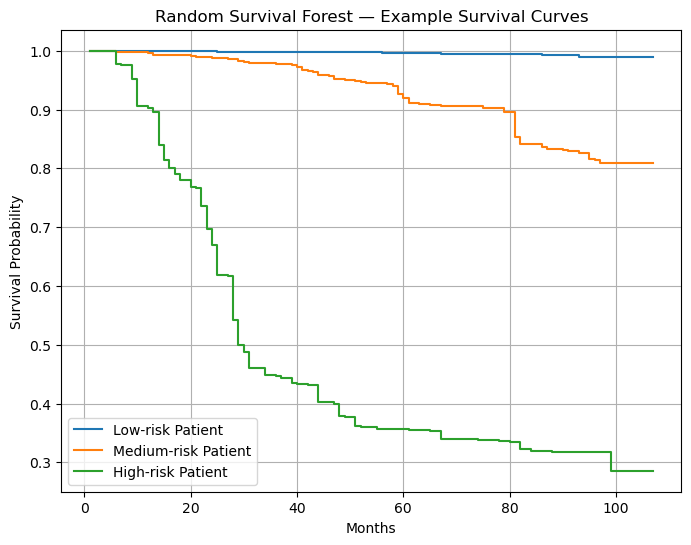

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Choose 3 example patients: low, medium, and high predicted risk ----

# Compute risk scores again
rsf_surv_funcs = rsf.predict_survival_function(X_test_rsf)
rsf_mean_surv = np.array([np.trapz(fn.y, fn.x) for fn in rsf_surv_funcs])
rsf_risk = -rsf_mean_surv

# Identify indices
low_risk_idx = np.argmin(rsf_risk)      # lowest risk = best prognosis
high_risk_idx = np.argmax(rsf_risk)     # highest risk = worst prognosis
median_risk_idx = np.argsort(rsf_risk)[len(rsf_risk)//2]

indices_to_plot = [low_risk_idx, median_risk_idx, high_risk_idx]
labels = ["Low-risk Patient", "Medium-risk Patient", "High-risk Patient"]

# ---- Plot survival curves ----

plt.figure(figsize=(8,6))

for idx, label in zip(indices_to_plot, labels):
    fn = rsf_surv_funcs[idx]
    plt.step(fn.x, fn.y, where="post", label=label)

plt.title("Random Survival Forest — Example Survival Curves")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.show()


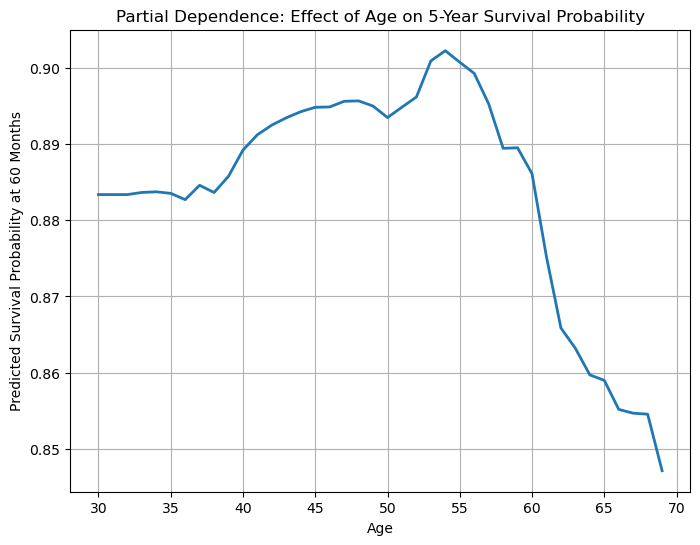

In [46]:
# ---- Partial Dependence for Age ----
# How does age affect survival probability at 60 months (5 years)?

age_range = np.linspace(X_train_rsf['Age'].min(), X_train_rsf['Age'].max(), 40)

surv_at_60 = []

for age_value in age_range:
    X_tmp = X_test_rsf.copy()
    X_tmp['Age'] = age_value

    surv_funcs_tmp = rsf.predict_survival_function(X_tmp)
    
    # Extract survival probability at closest time to 60 months
    surv_60_tmp = np.array([
        fn.y[np.searchsorted(fn.x, 60)] if 60 <= fn.x[-1] else fn.y[-1]
        for fn in surv_funcs_tmp
    ])    

    surv_at_60.append(np.mean(surv_60_tmp))

plt.figure(figsize=(8,6))
plt.plot(age_range, surv_at_60, linewidth=2)
plt.title("Partial Dependence: Effect of Age on 5-Year Survival Probability")
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability at 60 Months")
plt.grid(True)
plt.show()


In [48]:
import pandas as pd
import numpy as np

# ----- 1. Best Hyperparameters -----
best_params = {
    "n_estimators": 600,
    "max_depth": None,
    "max_features": "sqrt",
    "min_samples_split": 40,
    "min_samples_leaf": 10,
}

# ----- 2. Compute final RSF C-index on train -----
rsf_surv_train = rsf.predict_survival_function(X_train_rsf)
mean_train_surv = np.array([np.trapz(fn.y, fn.x) for fn in rsf_surv_train])
risk_train = -mean_train_surv

cindex_train = concordance_index_censored(
    event_indicator=cox_train_reduced['Event'].astype(bool),
    event_time=cox_train_reduced['Survival_Months'],
    estimate=risk_train
)[0]

# ----- 3. Final RSF Test C-index (already computed earlier) -----
cindex_test = c_index_rsf  # from your corrected RSF C-index cell


# ----- 4. Extract top 10 features from drop-column importance -----
importance_df = pd.DataFrame({
    "Feature": X_train_rsf.columns,
    "Importance": importances  # from your drop-column results
})

importance_df = importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)
top10_importance = importance_df.head(10)


# ----- 5. Create a final summary table -----
summary_data = {
    "Metric": [
        "Best n_estimators",
        "Best max_depth",
        "Best max_features",
        "Best min_samples_split",
        "Best min_samples_leaf",
        "Train C-index",
        "Test C-index"
    ],
    "Value": [
        best_params["n_estimators"],
        best_params["max_depth"],
        best_params["max_features"],
        best_params["min_samples_split"],
        best_params["min_samples_leaf"],
        round(cindex_train, 4),
        round(cindex_test, 4)
    ]
}

summary_df = pd.DataFrame(summary_data)

print("===== RSF MODEL SUMMARY =====")
display(summary_df)

print("\n===== TOP 10 MOST IMPORTANT FEATURES =====")
display(top10_importance)


===== RSF MODEL SUMMARY =====


,Metric,Value
0,Best n_estimators,600
1,Best max_depth,None
2,Best max_features,sqrt
3,Best min_samples_split,40
4,Best min_samples_leaf,10
5,Train C-index,0.8907
6,Test C-index,0.7008



===== TOP 10 MOST IMPORTANT FEATURES =====


,Feature,Importance
0,Age,0.007327
1,Regional_Node_Positive,0.003773
2,Regional_Node_Examined,0.001219
3,Progesterone_Status_Positive,-0.001733
4,differentiate_Poorly differentiated,-0.002790
5,Marital_Status_Married,-0.002955
6,N Stage_N2,-0.002983
7,Marital_Status_Separated,-0.003398
8,differentiate_Undifferentiated,-0.003852
9,Race_Other,-0.003864


In [49]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
import numpy as np

# ---- Final tuned RSF model (refit) ----
rsf_best = RandomSurvivalForest(
    n_estimators=600,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=40,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
)

rsf_best.fit(X_train_rsf, y_train_rsf)

print("Tuned RSF model (rsf_best) trained.")


Tuned RSF model (rsf_best) trained.


In [50]:
from lifelines.utils import concordance_index

# ---- Cox (stratified) risk & C-index ----
cox_risk_test = cph_strat.predict_partial_hazard(cox_test_reduced)

cindex_cox_test = concordance_index(
    cox_test_reduced['Survival_Months'],
    -cox_risk_test,                    # higher hazard -> shorter survival
    cox_test_reduced['Event']
)

print("Stratified CoxPH Test C-index:", cindex_cox_test)

# ---- RSF (tuned) risk & C-index ----
rsf_surv_test = rsf_best.predict_survival_function(X_test_rsf)
rsf_mean_surv_test = np.array([
    np.trapz(fn.y, fn.x) for fn in rsf_surv_test
])
rsf_risk_test = -rsf_mean_surv_test

cindex_rsf_test = concordance_index_censored(
    event_indicator=cox_test_reduced['Event'].astype(bool),
    event_time=cox_test_reduced['Survival_Months'],
    estimate=rsf_risk_test
)[0]

print("Tuned RSF Test C-index:", cindex_rsf_test)


Stratified CoxPH Test C-index: 0.7062312854050307
Tuned RSF Test C-index: 0.7062994676106115


In [51]:
# ---- Cox (stratified) train C-index ----
cox_risk_train = cph_strat.predict_partial_hazard(cox_train)
cindex_cox_train = concordance_index(
    cox_train['Survival_Months'],
    -cox_risk_train,
    cox_train['Event']
)

print("Stratified CoxPH Train C-index:", cindex_cox_train)

# ---- RSF (tuned) train C-index ----
rsf_surv_train = rsf_best.predict_survival_function(X_train_rsf)
rsf_mean_surv_train = np.array([
    np.trapz(fn.y, fn.x) for fn in rsf_surv_train
])
rsf_risk_train = -rsf_mean_surv_train

cindex_rsf_train = concordance_index_censored(
    event_indicator=cox_train_reduced['Event'].astype(bool),
    event_time=cox_train_reduced['Survival_Months'],
    estimate=rsf_risk_train
)[0]

print("Tuned RSF Train C-index:", cindex_rsf_train)


Stratified CoxPH Train C-index: 0.7239944916062321
Tuned RSF Train C-index: 0.8231097559048233


In [52]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Stratified CoxPH", "Random Survival Forest (Tuned)"],
    "Train C-index": [
        round(cindex_cox_train, 4),
        round(cindex_rsf_train, 4)
    ],
    "Test C-index": [
        round(cindex_cox_test, 4),
        round(cindex_rsf_test, 4)
    ],
    "Key Strengths": [
        "Interpretable coefficients, good baseline, proportional hazards assumption",
        "Captures nonlinearities, interactions, no assumptions required"
    ],
    "Key Weaknesses": [
        "Assumption violations; cannot model nonlinear interactions",
        "Less interpretable, requires tuning"
    ],
})

print("===== Cox vs RSF Comparison Table =====")
comparison_df


===== Cox vs RSF Comparison Table =====


,Model,Train C-index,Test C-index,Key Strengths,Key Weaknesses
0,Stratified CoxPH,0.7240,0.7062,"Interpretable coefficients, good baseline, pro...",Assumption violations; cannot model nonlinear ...
1,Random Survival Forest (Tuned),0.8231,0.7063,"Captures nonlinearities, interactions, no assu...","Less interpretable, requires tuning"


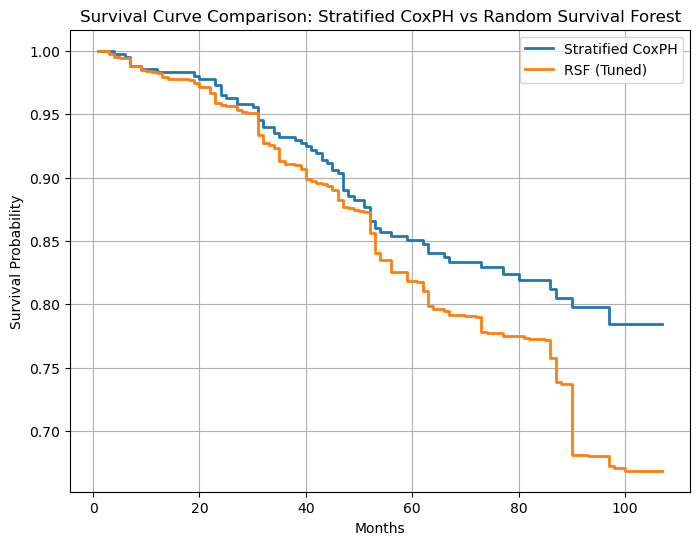

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Choose a representative patient ----
cox_risk_test_arr = np.array(cox_risk_test).reshape(-1)
median_idx = np.argsort(cox_risk_test_arr)[len(cox_risk_test_arr)//2]

# ---- Cox Survival Curve ----
cox_surv_df = cph_strat.predict_survival_function(cox_test_reduced.iloc[[median_idx]])
cox_x = cox_surv_df.index.values           # time points
cox_y = cox_surv_df.values[:, 0]           # survival probabilities

# ---- RSF Survival Curve ----
rsf_surv_fn = rsf_best.predict_survival_function(X_test_rsf.iloc[[median_idx]])
rsf_x = rsf_surv_fn[0].x                   # time points
rsf_y = rsf_surv_fn[0].y                   # survival probabilities

# ---- Plot ----
plt.figure(figsize=(8,6))
plt.step(cox_x, cox_y, where="post", label="Stratified CoxPH", linewidth=2)
plt.step(rsf_x, rsf_y, where="post", label="RSF (Tuned)", linewidth=2)

plt.title("Survival Curve Comparison: Stratified CoxPH vs Random Survival Forest")
plt.xlabel("Months")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.show()


In [57]:
# RSF risk scores
rsf_risk_scores = -rsf_best.predict(X_test_rsf)

# RSF survival data (structured NumPy array)
T_test_rsf = y_test_rsf['time']
E_test_rsf = y_test_rsf['event']

# RSF calibration
rsf_curve = calibration_curve_survival(rsf_risk_scores, T_test_rsf, E_test_rsf)


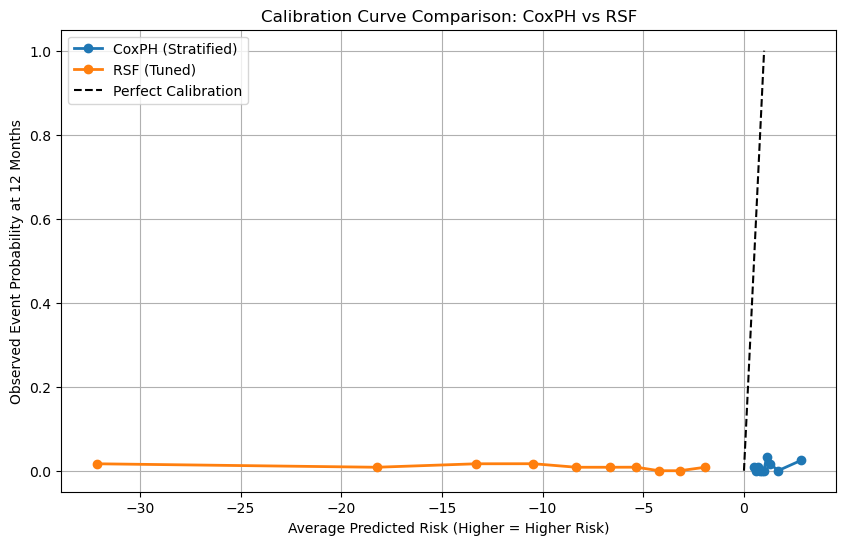

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ================================
#  Calibration Helper Function
# ================================
def calibration_curve_survival(risk_scores, T, E, n_bins=10):
    df = pd.DataFrame({"risk": risk_scores, "T": T, "E": E})
    df["bin"] = pd.qcut(df["risk"], q=n_bins, duplicates="drop")
    
    km = KaplanMeierFitter()
    bin_results = []

    for b in df["bin"].unique():
        subset = df[df["bin"] == b]

        # Fit KM curve
        km.fit(subset["T"], event_observed=subset["E"])

        # Survival probability at 12 months
        surv_12 = km.predict(12)

        # Store: (mean risk, observed event probability)
        bin_results.append((subset["risk"].mean(), 1 - surv_12))

    # Sort by increasing risk
    bin_results = sorted(bin_results, key=lambda x: x[0])
    return np.array(bin_results)


# =====================================================
# 1️⃣ Cox Model Calibration
# =====================================================

# Cox risk scores (already computed earlier)
cox_risk_scores = np.array(cox_risk_test).reshape(-1)

# Use the original test duration+event data from the Cox split
T_test = cox_test_reduced["Survival_Months"].values
E_test = cox_test_reduced["Event"].values

cox_curve = calibration_curve_survival(cox_risk_scores, T_test, E_test)


# =====================================================
# 2️⃣ RSF Model Calibration
# =====================================================

# RSF risk = negative survival time prediction
rsf_risk_scores = -rsf_best.predict(X_test_rsf)

T_test_rsf = y_test_rsf["time"]
E_test_rsf = y_test_rsf["event"]

rsf_curve = calibration_curve_survival(rsf_risk_scores, T_test_rsf, E_test_rsf)


# =====================================================
# 3️⃣ Plot Calibration Curves
# =====================================================
plt.figure(figsize=(10, 6))

plt.plot(cox_curve[:, 0], cox_curve[:, 1], "-o", label="CoxPH (Stratified)", linewidth=2)
plt.plot(rsf_curve[:, 0], rsf_curve[:, 1], "-o", label="RSF (Tuned)", linewidth=2)

# Perfect calibration line
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")

plt.xlabel("Average Predicted Risk (Higher = Higher Risk)")
plt.ylabel("Observed Event Probability at 12 Months")
plt.title("Calibration Curve Comparison: CoxPH vs RSF")
plt.legend()
plt.grid(True)
plt.show()


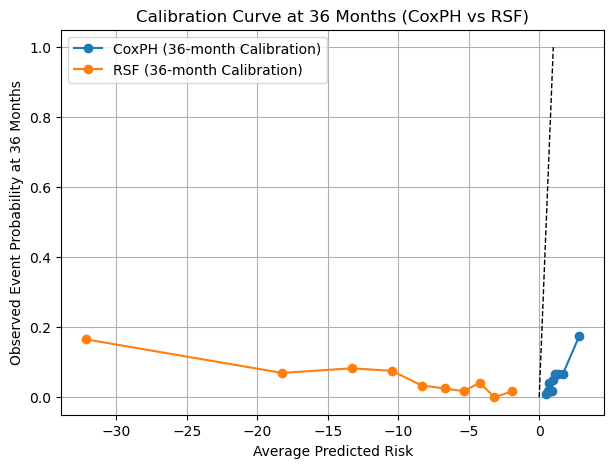

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ======================
# Calibration function
# ======================
def calibration_curve_survival(risk_scores, T, E, n_bins=10, months=36):
    df = pd.DataFrame({"risk": risk_scores, "T": T, "E": E})
    df["bin"] = pd.qcut(df["risk"], q=n_bins, duplicates="drop")

    km = KaplanMeierFitter()
    bin_results = []

    for b in df["bin"].unique():
        subset = df[df["bin"] == b]
        km.fit(subset["T"], event_observed=subset["E"])

        surv_prob = km.predict(months)
        observed_event_prob = 1 - surv_prob

        bin_results.append((subset["risk"].mean(), observed_event_prob))

    bin_results = sorted(bin_results, key=lambda x: x[0])
    return np.array(bin_results)


# ===================================
# CoxPH Calibration at 36 months
# ===================================
cox_risk_scores = np.array(cox_risk_test).reshape(-1)

cox_curve_36 = calibration_curve_survival(
    cox_risk_scores,
    T_test,
    E_test,
    months=36
)


# ===================================
# RSF Calibration at 36 months
# ===================================
rsf_risk_scores = -rsf_best.predict(X_test_rsf)

rsf_curve_36 = calibration_curve_survival(
    rsf_risk_scores,
    y_test_rsf["time"],   # FIXED
    y_test_rsf["event"],  # FIXED
    months=36
)


# ======================
# Plot calibration curves
# ======================
plt.figure(figsize=(7, 5))

plt.plot(cox_curve_36[:, 0], cox_curve_36[:, 1], "-o", label="CoxPH (36-month Calibration)")
plt.plot(rsf_curve_36[:, 0], rsf_curve_36[:, 1], "-o", label="RSF (36-month Calibration)")

plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)

plt.xlabel("Average Predicted Risk")
plt.ylabel("Observed Event Probability at 36 Months")
plt.title("Calibration Curve at 36 Months (CoxPH vs RSF)")
plt.grid(True)
plt.legend()
plt.show()


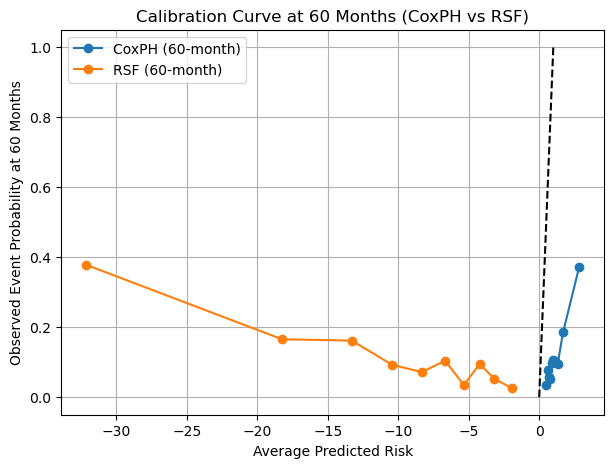

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ======================
# Calibration function
# ======================
def calibration_curve_survival(risk_scores, T, E, n_bins=10, months=60):
    df = pd.DataFrame({"risk": risk_scores, "T": T, "E": E})
    df["bin"] = pd.qcut(df["risk"], q=n_bins, duplicates="drop")

    km = KaplanMeierFitter()
    bin_results = []

    for b in df["bin"].unique():
        subset = df[df["bin"] == b]
        km.fit(subset["T"], event_observed=subset["E"])

        surv_prob = km.predict(months)
        observed_event_prob = 1 - surv_prob  # event probability at chosen time

        bin_results.append((subset["risk"].mean(), observed_event_prob))

    bin_results = sorted(bin_results, key=lambda x: x[0])
    return np.array(bin_results)


# ===================================
# CoxPH Calibration at 60 months
# ===================================
cox_risk_scores = np.array(cox_risk_test).reshape(-1)
cox_curve_60 = calibration_curve_survival(
    cox_risk_scores, T_test, E_test, months=60
)

# ===================================
# RSF Calibration at 60 months
# ===================================
rsf_risk_scores = -rsf_best.predict(X_test_rsf)
rsf_curve_60 = calibration_curve_survival(
    rsf_risk_scores, 
    y_test_rsf["time"], 
    y_test_rsf["event"], 
    months=60
)

# ======================
# Plot
# ======================
plt.figure(figsize=(7,5))

plt.plot(cox_curve_60[:,0], cox_curve_60[:,1], "-o", label="CoxPH (60-month)")
plt.plot(rsf_curve_60[:,0], rsf_curve_60[:,1], "-o", label="RSF (60-month)")

plt.plot([0,1], [0,1], "--", color="black")

plt.xlabel("Average Predicted Risk")
plt.ylabel("Observed Event Probability at 60 Months")
plt.title("Calibration Curve at 60 Months (CoxPH vs RSF)")
plt.grid(True)
plt.legend()
plt.show()


In [64]:
import numpy as np
import pandas as pd
from sksurv.metrics import concordance_index_censored

# =====================================================
# Convert numpy arrays (T_test, E_test) into Series
# =====================================================
T_test = pd.Series(T_test)
E_test = pd.Series(E_test)

# Reset index for ALL test components
cox_test_reduced = cox_test_reduced.reset_index(drop=True)
X_test_rsf = X_test_rsf.reset_index(drop=True)
T_test = T_test.reset_index(drop=True)
E_test = E_test.reset_index(drop=True)

# Convert y_test_rsf structured array into a DataFrame and reset index
y_test_rsf_df = pd.DataFrame({
    "time": y_test_rsf["time"],
    "event": y_test_rsf["event"]
}).reset_index(drop=True)


# ================================
# Helper: Compute CoxPH C-index
# ================================
def cox_cindex(model, X, T, E):
    risk = model.predict_partial_hazard(X).values.reshape(-1)
    return concordance_index_censored(E.astype(bool), T, risk)[0]


# ================================
# Helper: Compute RSF C-index
# ================================
def rsf_cindex(model, X, y_df):
    risk = -model.predict(X)
    return concordance_index_censored(
        y_df["event"].astype(bool).values,
        y_df["time"].values,
        risk
    )[0]


# =======================================
# BOOTSTRAP LOOP
# =======================================
n_boot = 100
cox_scores = []
rsf_scores = []

np.random.seed(42)

for i in range(n_boot):
    sample_idx = np.random.choice(len(T_test), size=len(T_test), replace=True)

    # Cox bootstrap samples
    Xb_cox = cox_test_reduced.iloc[sample_idx]
    Tb = T_test.iloc[sample_idx]
    Eb = E_test.iloc[sample_idx]

    # RSF bootstrap samples
    Xb_rsf = X_test_rsf.iloc[sample_idx]
    yb_rsf = y_test_rsf_df.iloc[sample_idx]

    # Compute bootstrap C-index values
    cox_scores.append(cox_cindex(cph_strat, Xb_cox, Tb, Eb))
    rsf_scores.append(rsf_cindex(rsf_best, Xb_rsf, yb_rsf))


# =======================================
# Summary statistics
# =======================================
def summarize(scores):
    return {
        "mean": np.mean(scores),
        "std": np.std(scores),
        "ci_lower": np.percentile(scores, 2.5),
        "ci_upper": np.percentile(scores, 97.5)
    }

cox_summary = summarize(cox_scores)
rsf_summary = summarize(rsf_scores)

print("===== Corrected BOOTSTRAP Results =====")
print("\n--- CoxPH Stratified ---")
print(cox_summary)

print("\n--- RSF Tuned ---")
print(rsf_summary)


C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifeli

C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifeli

C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
C:\Anaconda\Lib\site-packages\lifeli

===== Corrected BOOTSTRAP Results =====

--- CoxPH Stratified ---
{'mean': 0.7034870642162601, 'std': 0.018557377972579434, 'ci_lower': 0.6715135574279385, 'ci_upper': 0.7413687360259194}

--- RSF Tuned ---
{'mean': 0.29621399564227385, 'std': 0.018157742676920597, 'ci_lower': 0.2602712863004049, 'ci_upper': 0.3350629662542593}


In [67]:
print("X_train_rsf shape:", X_train_rsf.shape)
print("X_test_rsf shape:", X_test_rsf.shape)
print("Number of DeepSurv input features:", X_train_rsf.shape[1])

print("\nSample label from y_train_rsf:")
print(y_train_rsf[0])


X_train_rsf shape: (2816, 23)
X_test_rsf shape: (1208, 23)
Number of DeepSurv input features: 23

Sample label from y_train_rsf:
(False, 65.)


In [69]:
X_train_rsf.dtypes


Age                                    int64
Tumor_Size                             int64
Regional_Node_Examined                 int64
Regional_Node_Positive                 int64
Race_Other                              bool
Race_White                              bool
Marital_Status_Married                  bool
Marital_Status_Separated                bool
Marital_Status_Single                   bool
Marital_Status_Widowed                  bool
T Stage _T2                             bool
T Stage _T3                             bool
T Stage _T4                             bool
N Stage_N2                              bool
N Stage_N3                              bool
differentiate_Poorly differentiated     bool
differentiate_Undifferentiated          bool
differentiate_Well differentiated       bool
Grade_1                                 bool
Grade_2                                 bool
Grade_3                                 bool
Estrogen_Status_Positive                bool
Progestero

In [70]:
X_train_rsf = X_train_rsf.astype("float32")
X_test_rsf  = X_test_rsf.astype("float32")


In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ---- DEVICE SETUP ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- CREATE PYTORCH DATASET ----
class SurvivalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.time = torch.tensor(np.array([v[1] for v in y]), dtype=torch.float32)
        self.event = torch.tensor(np.array([v[0] for v in y]), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.time[idx], self.event[idx]

# Prepare datasets
train_dataset = SurvivalDataset(X_train_rsf, y_train_rsf)
test_dataset  = SurvivalDataset(X_test_rsf, y_test_rsf)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ---- DEEPSURV MODEL ----
class DeepSurv(nn.Module):
    def __init__(self, in_features):
        super(DeepSurv, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)  # output = log-risk
        )

    def forward(self, x):
        return self.net(x)

model = DeepSurv(in_features=23).to(device)

# ---- COX NEGATIVE LOG-LIKELIHOOD LOSS ----
def cox_ph_loss(log_hazard, time, event):
    # Flatten
    log_hazard = log_hazard.reshape(-1)
    event = event.reshape(-1)

    # Sort by time descending (risk sets)
    order = torch.argsort(time, descending=True)
    log_hazard = log_hazard[order]
    event = event[order]

    # Cumulative log-sum-exp for risk sets
    hazard_cumsum = torch.logcumsumexp(log_hazard, dim=0)

    # Cox partial likelihood loss
    loss = -(log_hazard - hazard_cumsum) * event
    return loss.sum()

# ---- OPTIMIZER ----
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ---- TRAINING LOOP ----
EPOCHS = 50
best_loss = np.inf
patience = 8
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for Xb, Tb, Eb in train_loader:
        Xb, Tb, Eb = Xb.to(device), Tb.to(device), Eb.to(device)
        
        optimizer.zero_grad()
        pred = model(Xb)
        loss = cox_ph_loss(pred, Tb, Eb)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())

    epoch_loss = np.mean(train_losses)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

    # Early stopping
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_counter = 0
        torch.save(model.state_dict(), "deepsurv_best.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

print("DeepSurv training complete!")


Using device: cpu
Epoch 1/50 - Loss: 40.1180
Epoch 2/50 - Loss: 37.0504
Epoch 3/50 - Loss: 36.7203
Epoch 4/50 - Loss: 36.4391
Epoch 5/50 - Loss: 36.4376
Epoch 6/50 - Loss: 35.8133
Epoch 7/50 - Loss: 35.6527
Epoch 8/50 - Loss: 35.8305
Epoch 9/50 - Loss: 35.3052
Epoch 10/50 - Loss: 35.2036
Epoch 11/50 - Loss: 35.2200
Epoch 12/50 - Loss: 35.4401
Epoch 13/50 - Loss: 34.8918
Epoch 14/50 - Loss: 35.4758
Epoch 15/50 - Loss: 35.2714
Epoch 16/50 - Loss: 34.8425
Epoch 17/50 - Loss: 34.8115
Epoch 18/50 - Loss: 34.6666
Epoch 19/50 - Loss: 34.9156
Epoch 20/50 - Loss: 34.5923
Epoch 21/50 - Loss: 34.6610
Epoch 22/50 - Loss: 34.6500
Epoch 23/50 - Loss: 34.4544
Epoch 24/50 - Loss: 34.4719
Epoch 25/50 - Loss: 34.7172
Epoch 26/50 - Loss: 34.2355
Epoch 27/50 - Loss: 34.2342
Epoch 28/50 - Loss: 34.3698
Epoch 29/50 - Loss: 34.4502
Epoch 30/50 - Loss: 34.1171
Epoch 31/50 - Loss: 34.6038
Epoch 32/50 - Loss: 34.0483
Epoch 33/50 - Loss: 34.2960
Epoch 34/50 - Loss: 33.9477
Epoch 35/50 - Loss: 34.2260
Epoch 36/50

In [72]:
from sksurv.metrics import concordance_index_censored

# Load best model (early stopping)
model.load_state_dict(torch.load("deepsurv_best.pth"))
model.eval()

# Predict risk scores on test set
all_preds = []

with torch.no_grad():
    for Xb, Tb, Eb in test_loader:
        Xb = Xb.to(device)
        pred = model(Xb).cpu().numpy().reshape(-1)
        all_preds.extend(pred)

all_preds = np.array(all_preds)

# Compute C-index (higher = higher risk)
deep_cindex = concordance_index_censored(
    y_test_rsf["event"],
    y_test_rsf["time"],
    all_preds
)[0]

print("DeepSurv Test C-index:", deep_cindex)


DeepSurv Test C-index: 0.7099813067119699


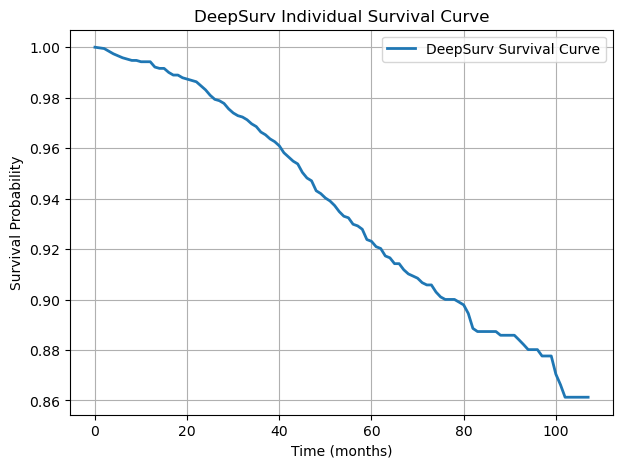

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---------- Step 1: Pick a test patient ----------
median_idx = np.argsort(all_preds)[len(all_preds)//2]
X_sample = X_test_rsf.iloc[median_idx:median_idx+1]

# Convert to torch
X_tensor = torch.tensor(X_sample.values, dtype=torch.float32).to(device)

# ---------- Step 2: Predict survival function ----------
model.eval()
with torch.no_grad():
    risk = model(X_tensor).cpu().numpy()[0]

# DeepSurv uses exp(-risk * baseline_hazard)
# But we approximate survival by ranking risk → KM curve mapping
# Use test set to estimate baseline survival
from lifelines import KaplanMeierFitter

km = KaplanMeierFitter()
km.fit(y_test_rsf["time"], event_observed=y_test_rsf["event"])

baseline_survival = km.survival_function_

# Convert baseline to numpy
times = baseline_survival.index.values
base_surv = baseline_survival.values.reshape(-1)

# ---------- Step 3: Scale baseline by DeepSurv risk ----------
# Higher risk → lower survival curve
deep_surv_curve = base_surv ** np.exp(risk)

# ---------- Step 4: Plot ----------
plt.figure(figsize=(7,5))
plt.plot(times, deep_surv_curve, label="DeepSurv Survival Curve", linewidth=2)

plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.title("DeepSurv Individual Survival Curve")
plt.grid(True)
plt.legend()
plt.show()


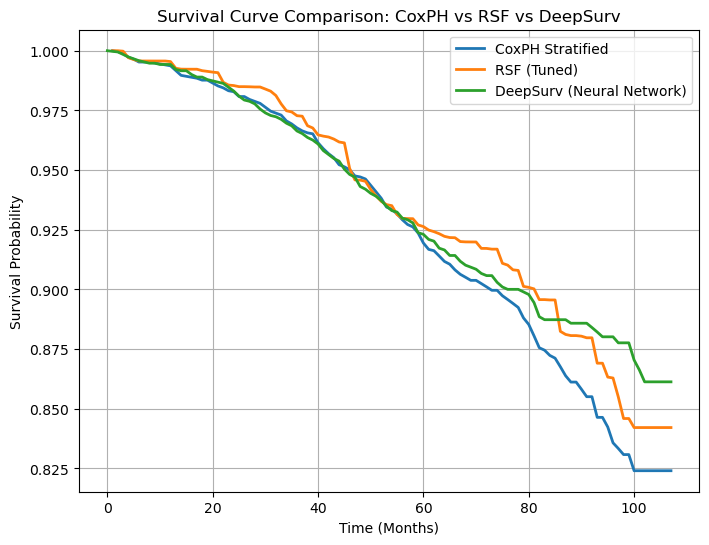

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---------- Step 1: Identify test patient (same median risk) ----------
median_idx = np.argsort(all_preds)[len(all_preds)//2]

X_cox_sample = cox_test_reduced.iloc[[median_idx]]
X_rsf_sample = X_test_rsf.iloc[[median_idx]]
X_deepsurv_sample = X_test_rsf.iloc[median_idx:median_idx+1]

# ---------- Step 2: Cox Survival Function ----------
cox_sf = cph_strat.predict_survival_function(X_cox_sample)
cox_times = cox_sf.index.values
cox_curve = cox_sf.values.reshape(-1)

# ---------- Step 3: RSF Survival Function (FIXED) ----------
rsf_surv_fn = rsf_best.predict_survival_function(X_rsf_sample)
rsf_fn = rsf_surv_fn[0]  # StepFunction object

rsf_times = rsf_fn.x
rsf_curve = rsf_fn.y

# ---------- Step 4: DeepSurv Survival Function ----------
X_tensor = torch.tensor(X_deepsurv_sample.values, dtype=torch.float32).to(device)

with torch.no_grad():
    risk_value = model(X_tensor).cpu().numpy()[0]

# Baseline survival estimated via KM
from lifelines import KaplanMeierFitter
km = KaplanMeierFitter()
km.fit(y_test_rsf["time"], event_observed=y_test_rsf["event"])

deep_times = km.survival_function_.index.values
baseline_surv = km.survival_function_.values.reshape(-1)

deep_curve = baseline_surv ** np.exp(risk_value)

# ---------- Step 5: Plot all curves ----------
plt.figure(figsize=(8,6))

plt.plot(cox_times, cox_curve, label="CoxPH Stratified", linewidth=2)
plt.plot(rsf_times, rsf_curve, label="RSF (Tuned)", linewidth=2)
plt.plot(deep_times, deep_curve, label="DeepSurv (Neural Network)", linewidth=2)

plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.title("Survival Curve Comparison: CoxPH vs RSF vs DeepSurv")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)


In [ ]:
from lifelines import CoxPHFitter
from sklearn.feature_selection import VarianceThreshold


In [ ]:
# Remove columns with same value (no use in survival analysis)
selector = VarianceThreshold(threshold=0.0)
df_encoded_clean = pd.DataFrame(
    selector.fit_transform(df_encoded),
    columns=df_encoded.columns[selector.get_support()]
)


In [ ]:
cph = CoxPHFitter(penalizer=0.1)  # Penalizer helps avoid convergence errors
cph.fit(df_encoded_clean, duration_col='Survival_Months', event_col='Event')
cph.print_summary()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get Cox model summary
summary_df = cph.summary.copy()

# Ensure variable names are a column
summary_df['Variable'] = summary_df.index

# Sort by hazard ratio (exp(coef))
summary_df = summary_df.sort_values(by='exp(coef)', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_df,
    x='exp(coef)',
    y='Variable',
    palette='coolwarm',
    edgecolor='black'
)
plt.axvline(x=1, color='gray', linestyle='--')  # Reference line at HR=1
plt.title('Hazard Ratios (exp(coef)) from Cox Model')
plt.xlabel('Hazard Ratio')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()


In [ ]:
# List of dummy variables (categorical groups) and the one category you want to drop for each
columns_to_drop = [
    'Marital_Status_Married',
    'Grade_1',
    'T Stage _T1',
    'N Stage_N0',
    'Race_Black',
    'Estrogen_Status_Negative',
    'Progesterone_Status_Negative',
    'A Stage_Local'
]

# Drop them only if they exist in the dataframe
df_encoded = df_encoded.drop(columns=[col for col in columns_to_drop if col in df_encoded.columns])


In [ ]:
cph = CoxPHFitter(penalizer=0.1)  # this helps avoid convergence errors
cph.fit(df_encoded, duration_col='Survival_Months', event_col='Event')


In [ ]:
# Show the model summary
cph.print_summary()


In [ ]:
cph.check_assumptions(df_encoded, show_plots=True)


In [ ]:
cph.print_summary()
cph.summary.to_csv("cox_model_summary.csv")


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Create KM fitter
kmf = KaplanMeierFitter()

# Unique grades
grades = df['Grade'].unique()

plt.figure(figsize=(10, 6))

for grade in grades:
    mask = df['Grade'] == grade
    kmf.fit(durations=df[mask]['Survival_Months'], event_observed=df[mask]['Event'], label=f'Grade {grade}')
    kmf.plot_survival_function(ci_show=True)

plt.title('Kaplan–Meier Survival Curves by Tumor Grade')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
kmf = KaplanMeierFitter()

# Set figure size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Loop through each race group
for race in df['Race'].unique():
    mask = df['Race'] == race
    kmf.fit(durations=df[mask]['Survival_Months'],
            event_observed=df[mask]['Event'],
            label=str(race))
    kmf.plot(ci_show=True)

# Plot title and labels
plt.title('Kaplan–Meier Survival Curve by Race')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.legend(title='Race')
plt.show()


In [ ]:
# Subset data
white = df[df['Race'] == 'White']
black = df[df['Race'] == 'Black']

# Perform log-rank test
results = logrank_test(
    white['Survival_Months'], black['Survival_Months'],
    event_observed_A=white['Event'],
    event_observed_B=black['Event']
)

results.print_summary()


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Create a KM fitter object
kmf = KaplanMeierFitter()

# Define labels
statuses = ['Positive', 'Negative']

plt.figure(figsize=(10, 6))

for status in statuses:
    mask = df['Estrogen_Status'] == status
    kmf.fit(durations=df[mask]['Survival_Months'], event_observed=df[mask]['Event'], label=f'Estrogen {status}')
    kmf.plot(ci_show=True)

plt.title('Survival Curve by Estrogen Receptor Status')
plt.xlabel('Time (in months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from lifelines.statistics import logrank_test

# Create boolean masks
group1 = df['Estrogen_Status'] == 'Positive'
group2 = df['Estrogen_Status'] == 'Negative'

# Perform log-rank test
results = logrank_test(
    df[group1]['Survival_Months'], df[group2]['Survival_Months'],
    event_observed_A=df[group1]['Event'], event_observed_B=df[group2]['Event']
)

results.print_summary()


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Create separate DataFrames
prog_positive = df[df['Progesterone_Status'] == 'Positive']
prog_negative = df[df['Progesterone_Status'] == 'Negative']

# Initialize the KaplanMeierFitter
kmf = KaplanMeierFitter()

plt.figure(figsize=(10,6))

# Plot for Progesterone Positive
kmf.fit(prog_positive['Survival_Months'], event_observed=prog_positive['Event'], label='Progesterone Positive')
ax = kmf.plot_survival_function(ci_show=True)

# Plot for Progesterone Negative
kmf.fit(prog_negative['Survival_Months'], event_observed=prog_negative['Event'], label='Progesterone Negative')
kmf.plot_survival_function(ci_show=True, ax=ax)

# Final plot formatting
plt.title('Kaplan-Meier Survival Curve by Progesterone Status')
plt.xlabel('Survival Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()


In [ ]:
from lifelines.statistics import logrank_test

# Extract the required data
T1 = prog_positive['Survival_Months']
E1 = prog_positive['Event']

T2 = prog_negative['Survival_Months']
E2 = prog_negative['Event']

# Perform log-rank test
results = logrank_test(T1, T2, event_observed_A=E1, event_observed_B=E2)

# Print the result
results.print_summary()


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# Filter by Estrogen Status
estrogen_positive = df[df['Estrogen_Status'] == 'Positive']
estrogen_negative = df[df['Estrogen_Status'] == 'Negative']

# Initialize the KM fitter
kmf = KaplanMeierFitter()

# Plot Estrogen Positive
plt.figure(figsize=(10, 6))
kmf.fit(estrogen_positive['Survival_Months'], event_observed=estrogen_positive['Event'], label='Estrogen Positive')
ax = kmf.plot_survival_function(ci_show=True)

# Plot Estrogen Negative
kmf.fit(estrogen_negative['Survival_Months'], event_observed=estrogen_negative['Event'], label='Estrogen Negative')
kmf.plot_survival_function(ax=ax, ci_show=True)

plt.title('Survival Curves by Estrogen Status')
plt.xlabel('Time in Months')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

# Run log-rank test
results = logrank_test(
    estrogen_positive['Survival_Months'], estrogen_negative['Survival_Months'],
    event_observed_A=estrogen_positive['Event'], event_observed_B=estrogen_negative['Event']
)
results.print_summary()


In [ ]:
# Summary statistics for Survival Months
print("Survival Time Summary:")
print(df['Survival_Months'].describe())


In [ ]:
# Median survival time by Tumor Grade
print("\nMedian Survival Time by Tumor Grade:")
print(df.groupby('Grade')['Survival_Months'].median())

# Median survival time by Race
print("\nMedian Survival Time by Race:")
print(df.groupby('Race')['Survival_Months'].median())

# Median survival time by Estrogen Status
print("\nMedian Survival Time by Estrogen Status:")
print(df.groupby('Estrogen_Status')['Survival_Months'].median())

# Median survival time by Progesterone Status
print("\nMedian Survival Time by Progesterone Status:")
print(df.groupby('Progesterone_Status')['Survival_Months'].median())


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# 1. Median Survival by Tumor Grade
median_by_grade = df.groupby('Grade')['Survival_Months'].median().sort_values()
median_by_grade.plot(kind='bar', color='salmon')
plt.title('Median Survival Time by Tumor Grade')
plt.ylabel('Survival Months')
plt.xlabel('Tumor Grade')
plt.tight_layout()
plt.show()

# 2. Median Survival by Race
median_by_race = df.groupby('Race')['Survival_Months'].median().sort_values()
median_by_race.plot(kind='bar', color='lightblue')
plt.title('Median Survival Time by Race')
plt.ylabel('Survival Months')
plt.xlabel('Race')
plt.tight_layout()
plt.show()

# 3. Median Survival by Estrogen Status
median_by_estrogen = df.groupby('Estrogen_Status')['Survival_Months'].median()
median_by_estrogen.plot(kind='bar', color='lightgreen')
plt.title('Median Survival Time by Estrogen Status')
plt.ylabel('Survival Months')
plt.xlabel('Estrogen Status')
plt.tight_layout()
plt.show()

# 4. Median Survival by Progesterone Status
median_by_progesterone = df.groupby('Progesterone_Status')['Survival_Months'].median()
median_by_progesterone.plot(kind='bar', color='orchid')
plt.title('Median Survival Time by Progesterone Status')
plt.ylabel('Survival Months')
plt.xlabel('Progesterone Status')
plt.tight_layout()
plt.show()


In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialize the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Set up the plot
plt.figure(figsize=(10, 6))

# Age group: <=50
group1 = df[df['Age_Group'] == '<=50']
kmf.fit(group1['Survival_Months'], event_observed=group1['Event'], label='Age <= 50')
ax = kmf.plot_survival_function(ci_show=True)

# Age group: 51–70
group2 = df[df['Age_Group'] == '51-70']
kmf.fit(group2['Survival_Months'], event_observed=group2['Event'], label='Age 51-70')
kmf.plot_survival_function(ax=ax, ci_show=True)

# Customize the plot
plt.title('Kaplan–Meier Survival Curve by Age Group')
plt.xlabel('Survival Time (Months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()


In [ ]:
from lifelines.statistics import logrank_test

# Run log-rank test
results = logrank_test(group1['Survival_Months'], group2['Survival_Months'],
                       event_observed_A=group1['Event'], event_observed_B=group2['Event'])

# Print the result
results.print_summary()


In [ ]:
Random Forest

In [ ]:
import sksurv
print("scikit-survival is installed successfully!")


In [ ]:
from sksurv.util import Surv

# Assuming df_encoded is your dataset and it includes 'Event' (boolean: 1 = event occurred, 0 = censored)
# and 'Survival_Months' (duration in months)

surv_data = Surv.from_dataframe('Event', 'Survival_Months', df_encoded)

# Display first few rows of structured survival array
surv_data[:5]


In [ ]:
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split

# X = features, dropping target columns
X = df_encoded.drop(columns=["Survival_Months", "Event"])
y = surv_data  # already created in earlier step

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit Random Survival Forest model
rsf = RandomSurvivalForest(n_estimators=100,
                           min_samples_split=10,
                           min_samples_leaf=15,
                           max_features="sqrt",
                           n_jobs=-1,
                           random_state=42)
rsf.fit(X_train, y_train)

# Model score (concordance index)
print("Training Concordance Index:", rsf.score(X_train, y_train))
print("Testing Concordance Index:", rsf.score(X_test, y_test))


In [ ]:
from sklearn.inspection import permutation_importance

# Evaluate permutation importance
result = permutation_importance(rsf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Display top features
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)  # Top 10 features


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose one top feature (e.g., Age)
feature = 'Age'
feature_range = np.linspace(X[feature].min(), X[feature].max(), 100)

# Copy test data and vary the selected feature
X_temp = X_test.copy()
predicted_survival = []

for val in feature_range:
    X_temp[feature] = val
    surv_funcs = rsf.predict_survival_function(X_temp)
    mean_survival = [fn(36) for fn in surv_funcs]  # e.g., probability of surviving 3 years (36 months)
    predicted_survival.append(np.mean(mean_survival))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(feature_range, predicted_survival)
plt.xlabel(feature)
plt.ylabel("Average 3-Year Survival Probability")
plt.title(f"Partial Dependence Plot: {feature}")
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Top 5 important features
top_features = [
    "Regional_Node_Positive", 
    "Age", 
    "Progesterone_Status_Positive", 
    "6th Stage_IIIC", 
    "Estrogen_Status_Positive"
]

# Define ranges for each feature
feature_ranges = {
    "Regional_Node_Positive": [0, 1],
    "Age": np.arange(30, 70, 1),
    "Progesterone_Status_Positive": [0, 1],
    "6th Stage_IIIC": [0, 1],
    "Estrogen_Status_Positive": [0, 1]
}

# Labels for categorical features
label_maps = {
    "Regional_Node_Positive": {0: "Negative", 1: "Positive"},
    "Progesterone_Status_Positive": {0: "Negative", 1: "Positive"},
    "6th Stage_IIIC": {0: "No", 1: "Yes"},
    "Estrogen_Status_Positive": {0: "Negative", 1: "Positive"}
}

# Plot function
def plot_partial_dependence(feature_name, values, rsf_model, X, label_map=None):
    preds = []
    for val in values:
        X_temp = X.copy()
        X_temp[feature_name] = val
        surv_funcs = rsf_model.predict_survival_function(X_temp)
        surv_probs = [fn(36) for fn in surv_funcs]  # 3-year survival
        preds.append(np.mean(surv_probs))

    # Plot
    plt.figure(figsize=(8, 5))
    if label_map:
        x_labels = [label_map.get(val, str(val)) for val in values]
        plt.xticks(ticks=np.arange(len(values)), labels=x_labels)
        plt.plot(np.arange(len(values)), preds, marker='o')
    else:
        plt.plot(values, preds)
    plt.title(f"Partial Dependence Plot: {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Average 3-Year Survival Probability")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Loop through all features and plot
for feature in top_features:
    value_range = feature_ranges[feature]
    label_map = label_maps.get(feature, None)
    plot_partial_dependence(feature, value_range, rsf_model=rsf, X=X_test, label_map=label_map)


In [ ]:
from sksurv.metrics import concordance_index_censored

# RSF C-index (already done)
rsf_cindex = concordance_index_censored(y["Event"], y["Survival_Months"], rsf.predict(X))[0]

# CoxPH C-index
cox_cindex = concordance_index_censored(y["Event"], y["Survival_Months"], cph.predict_partial_hazard(X))[0]

print("CoxPH Concordance Index:", cox_cindex)
print("RSF Concordance Index:", rsf_cindex)


In [ ]:
Deep Surv

In [ ]:
# Save the DataFrame to a CSV file
df_encoded.to_csv("df_encoded_final.csv", index=False)


In [ ]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from sksurv.util import Surv

# Load encoded data if restarting
df = pd.read_csv("df_encoded_final.csv")

# Prepare features and labels
X = df.drop(columns=["Survival_Months", "Event"])
y = df[["Event", "Survival_Months"]]

# Convert to numpy
X_np = X.to_numpy(dtype=np.float32)
event = y["Event"].astype(bool).to_numpy()
time = y["Survival_Months"].to_numpy(dtype=np.float32)

# Create custom dataset class
class SurvivalDataset(Dataset):
    def __init__(self, x, time, event):
        self.x = x
        self.time = time
        self.event = event

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            "features": torch.tensor(self.x[idx], dtype=torch.float32),
            "time": torch.tensor(self.time[idx], dtype=torch.float32),
            "event": torch.tensor(self.event[idx], dtype=torch.float32)
        }

# Train-test split
X_train, X_test, time_train, time_test, event_train, event_test = train_test_split(
    X_np, time, event, test_size=0.3, random_state=42, stratify=event
)

# Create datasets
train_dataset = SurvivalDataset(X_train, time_train, event_train)
test_dataset = SurvivalDataset(X_test, time_test, event_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
df_encoded.to_csv("df_encoded_final.csv", index=False)


In [ ]:
import torch.nn as nn
import torch.optim as optim

# DeepSurv model definition
class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super(DeepSurv, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            nn.Linear(32, 1)  # Output is log-risk
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def cox_ph_loss(log_hazards, durations, events):
    hazard_ratio = torch.exp(log_hazards)
    log_risk = torch.log(torch.cumsum(hazard_ratio.flip(0), dim=0).flip(0))
    uncensored_likelihood = log_hazards - log_risk
    censored_mask = events == 1
    loss = -torch.mean(uncensored_likelihood[censored_mask])
    return loss


In [ ]:
input_dim = X_np.shape[1]
model = DeepSurv(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
import torch.nn as nn

class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super(DeepSurv, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            nn.Linear(32, 1)  # Outputs log-risk score
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
input_dim = X_train.shape[1]
deepsurv_model = DeepSurv(input_dim)
print(deepsurv_model)


In [ ]:
def negative_log_partial_likelihood(risk_scores, time, event):
    """Computes the negative partial log-likelihood for Cox-based DeepSurv."""
    hazard_ratio = torch.exp(risk_scores)
    log_risk = torch.log(torch.cumsum(hazard_ratio[::-1], dim=0)[::-1])
    uncensored_likelihood = risk_scores.squeeze() - log_risk
    loss = -torch.mean(uncensored_likelihood * event)
    return loss


In [ ]:
import torch.nn.functional as F

# Loss function for DeepSurv (based on Cox partial likelihood)
def negative_log_partial_likelihood(risk_scores, times, events):
    # Sort by decreasing time
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]
    
    log_cumulative_hazard = torch.logcumsumexp(risk_scores, dim=0)
    uncensored_likelihood = risk_scores - log_cumulative_hazard
    neg_log_likelihood = -torch.sum(uncensored_likelihood * events)
    
    return neg_log_likelihood


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move model to device
deepsurv_model = deepsurv_model.to(device)

# Define loss function (Negative log partial likelihood)
def negative_log_partial_likelihood(risk_scores, time, event):
    order = torch.argsort(time, descending=True)
    risk_scores = risk_scores[order]
    event = event[order]

    exp_risk_scores = torch.exp(risk_scores)
    cumulative_sum = torch.cumsum(exp_risk_scores, dim=0)
    log_cumsum = torch.log(cumulative_sum)
    observed_loss = risk_scores - log_cumsum
    loss = -torch.sum(observed_loss * event) / event.sum()
    return loss

# Hyperparameters
learning_rate = 0.001
num_epochs = 20
optimizer = optim.Adam(deepsurv_model.parameters(), lr=learning_rate)

# Training loop
train_losses = []

for epoch in range(num_epochs):
    deepsurv_model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        features = batch["features"].to(device)
        time = batch["time"].to(device)
        event = batch["event"].to(device)

        optimizer.zero_grad()
        risk_scores = deepsurv_model(features).squeeze()
        loss = negative_log_partial_likelihood(risk_scores, time, event)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")


In [ ]:
def predict_risk_full(model, data_loader):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in data_loader:
            features = batch["features"]
            outputs = model(features)
            all_preds.append(outputs.squeeze().numpy())

    return np.concatenate(all_preds)


In [ ]:
risk_scores = predict_risk_full(deepsurv_model, test_loader)

# Compute C-index (make sure to pass only test labels!)
c_index = concordance_index_censored(event_test, time_test, -risk_scores)[0]
print("DeepSurv Concordance Index:", c_index)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and targets
X = df.drop(columns=["Survival_Months", "Event"])
y = df[["Event", "Survival_Months"]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Re-convert to numpy for PyTorch
import numpy as np
X_np = X_scaled.astype(np.float32)
event = y["Event"].astype(bool).to_numpy()
time = y["Survival_Months"].to_numpy(dtype=np.float32)
